<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Aishwarya_complete_SIA_analysis_9725.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import pandas as pd
import numpy as np


In [61]:
df = pd.read_excel('/content/drive/MyDrive/aishwarya preopkhkvax.xlsx')

In [62]:
import seaborn as sns

In [63]:
df.columns

Index(['pre-op KH', 'pre-op KV', 'pre-op Axis', 'post-op KH', 'post-op KV',
       'post-op Axis'],
      dtype='object')

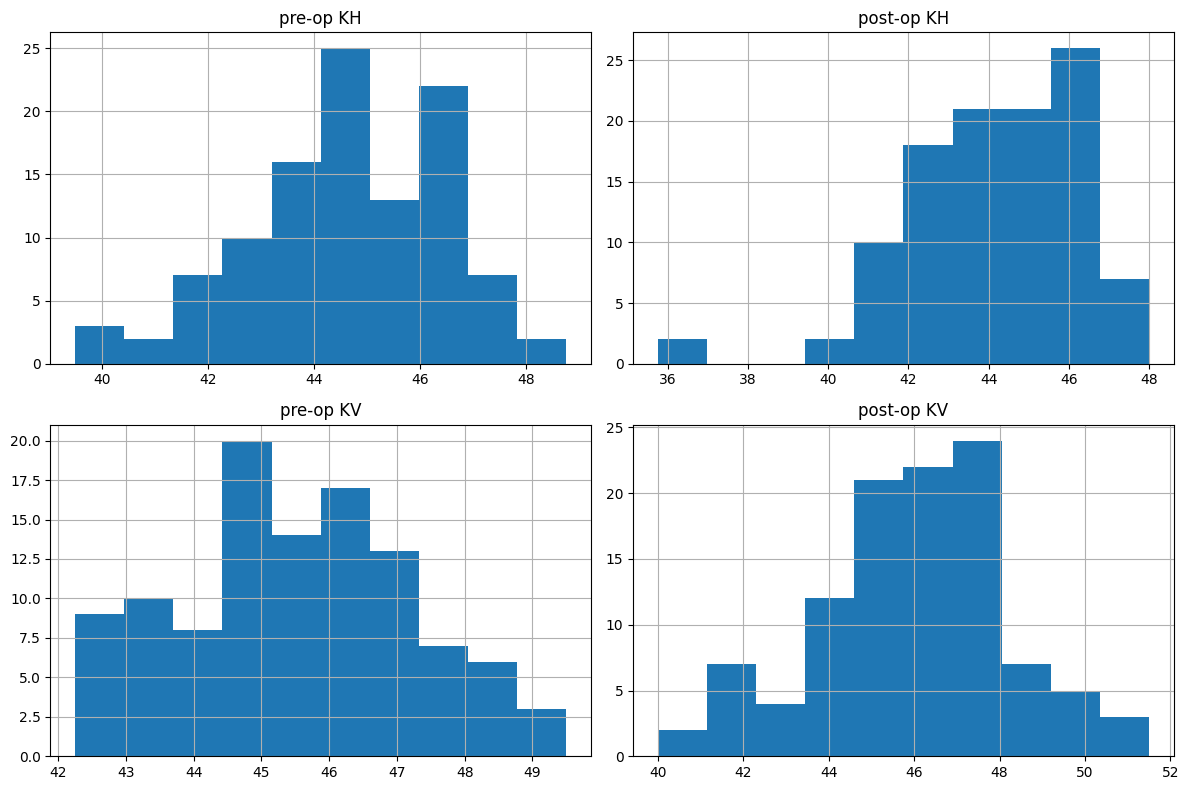

In [64]:
# prompt: Histogram pre-op KH', 'pre-op KV', 'pre-op Axis', 'post-op KH', 'post-op KV',
#        'post-op Axis'

import matplotlib.pyplot as plt

# Select the columns for histogram
cols_to_hist = ['pre-op KH', 'post-op KH', 'pre-op KV', 'post-op KV']

# Create histograms for each selected column
df[cols_to_hist].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# You can also use seaborn for potentially nicer looking histograms
# for col in cols_to_hist:
#     plt.figure() # Create a new figure for each histogram
#     sns.histplot(data=df, x=col, kde=True)
#     plt.title(f'Histogram of {col}')
#     plt.show()


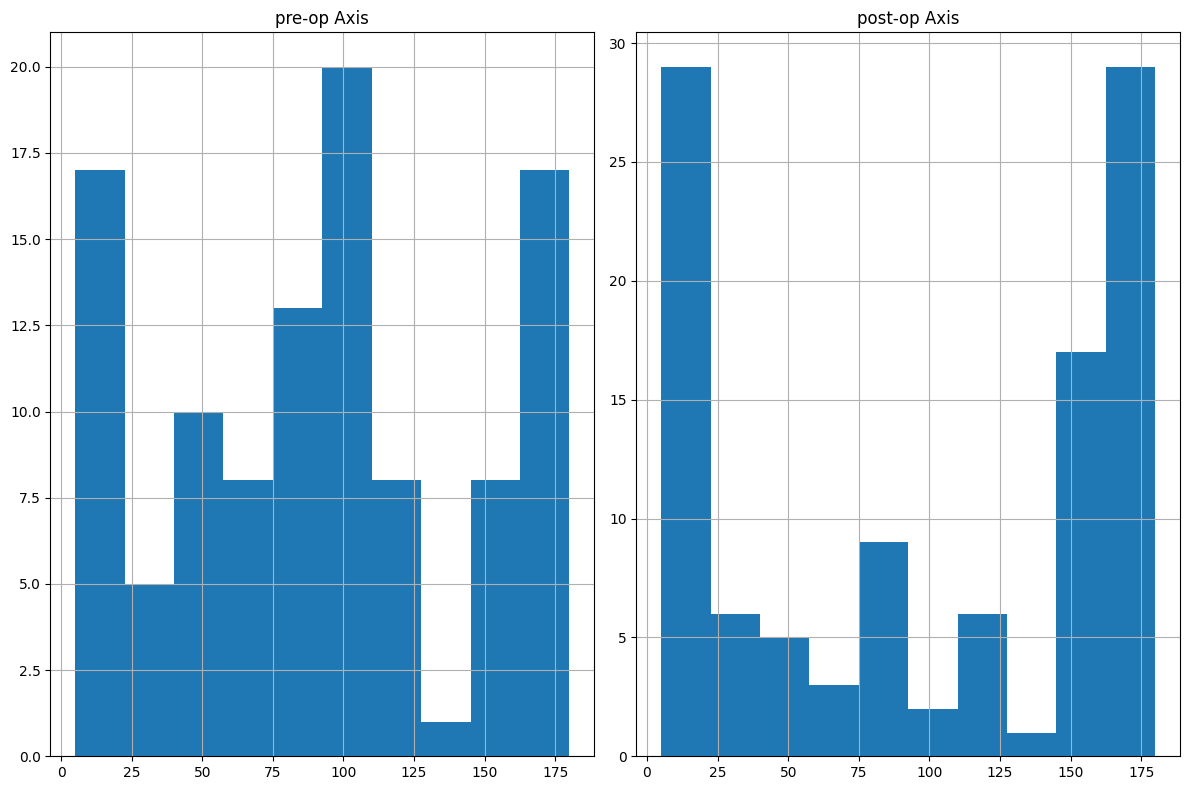

In [65]:
# prompt: Histogram pre-op KH', 'pre-op KV', 'pre-op Axis', 'post-op KH', 'post-op KV',
#        'post-op Axis'

import matplotlib.pyplot as plt

# Select the columns for histogram
cols_to_hist = ['pre-op Axis', 'post-op Axis']

# Create histograms for each selected column
df[cols_to_hist].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# You can also use seaborn for potentially nicer looking histograms
# for col in cols_to_hist:
#     plt.figure() # Create a new figure for each histogram
#     sns.histplot(data=df, x=col, kde=True)
#     plt.title(f'Histogram of {col}')
#     plt.show()


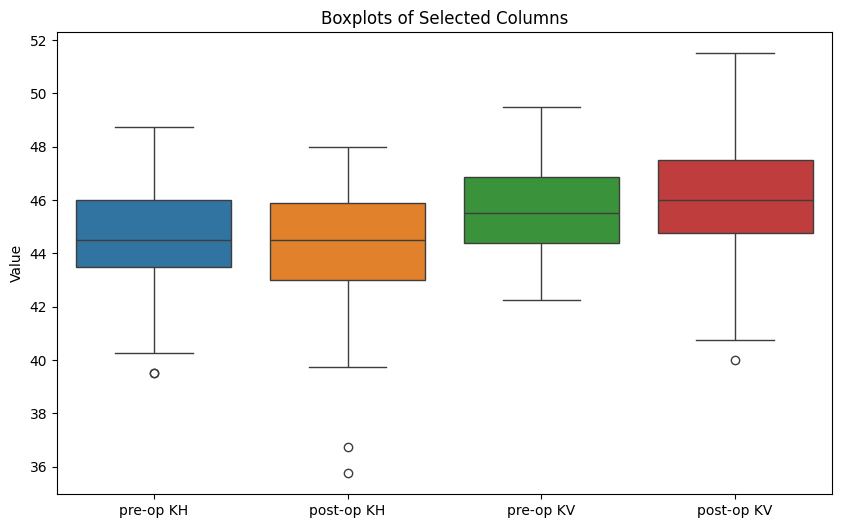

In [66]:
# prompt: Boxplots

import matplotlib.pyplot as plt
# Select the columns for boxplots
cols_to_boxplot = ['pre-op KH', 'post-op KH', 'pre-op KV', 'post-op KV']

# Create boxplots for each selected column
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[cols_to_boxplot])
plt.title('Boxplots of Selected Columns')
plt.ylabel('Value')
plt.show()

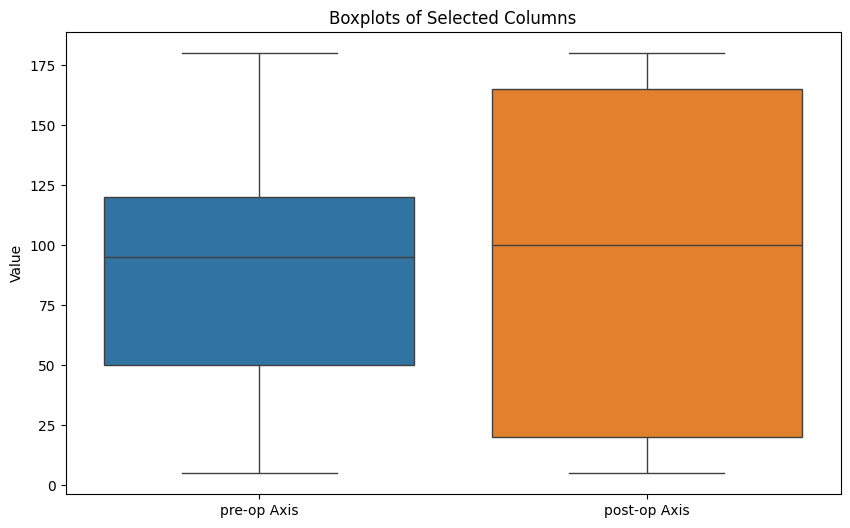

In [67]:
# prompt: Boxplots

import matplotlib.pyplot as plt
# Select the columns for boxplots
cols_to_boxplot = ['pre-op Axis', 'post-op Axis']

# Create boxplots for each selected column
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[cols_to_boxplot])
plt.title('Boxplots of Selected Columns')
plt.ylabel('Value')
plt.show()

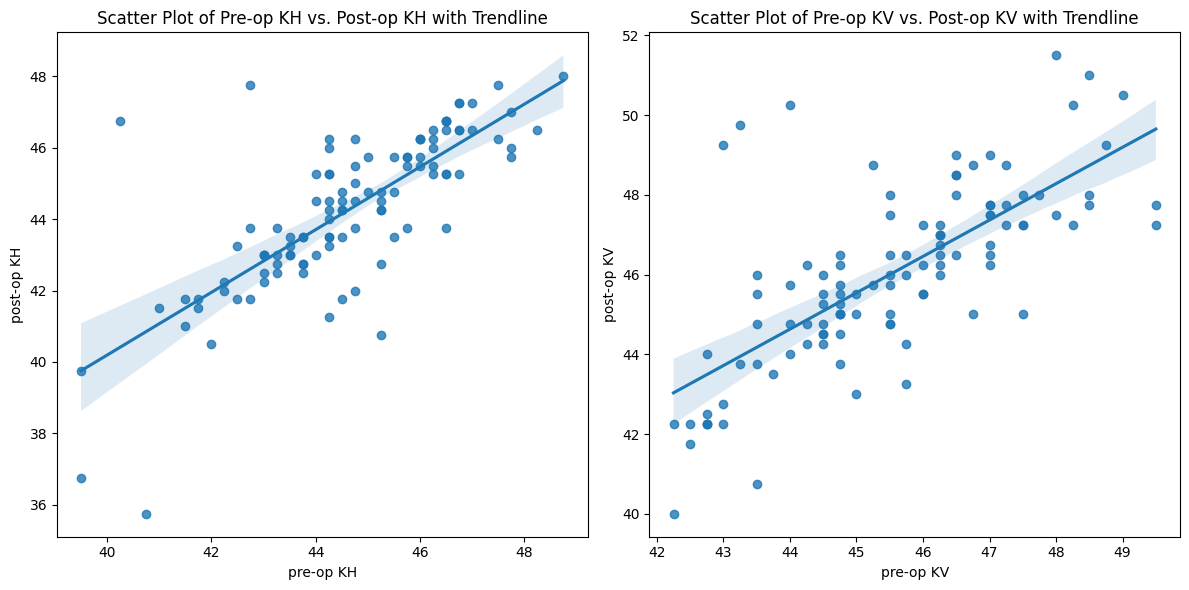

In [68]:
# prompt: Scatter plots trendline side by side

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.regplot(x='pre-op KH', y='post-op KH', data=df, ax=axes[0])
axes[0].set_title('Scatter Plot of Pre-op KH vs. Post-op KH with Trendline')

sns.regplot(x='pre-op KV', y='post-op KV', data=df, ax=axes[1])
axes[1].set_title('Scatter Plot of Pre-op KV vs. Post-op KV with Trendline')

plt.tight_layout()
plt.show()

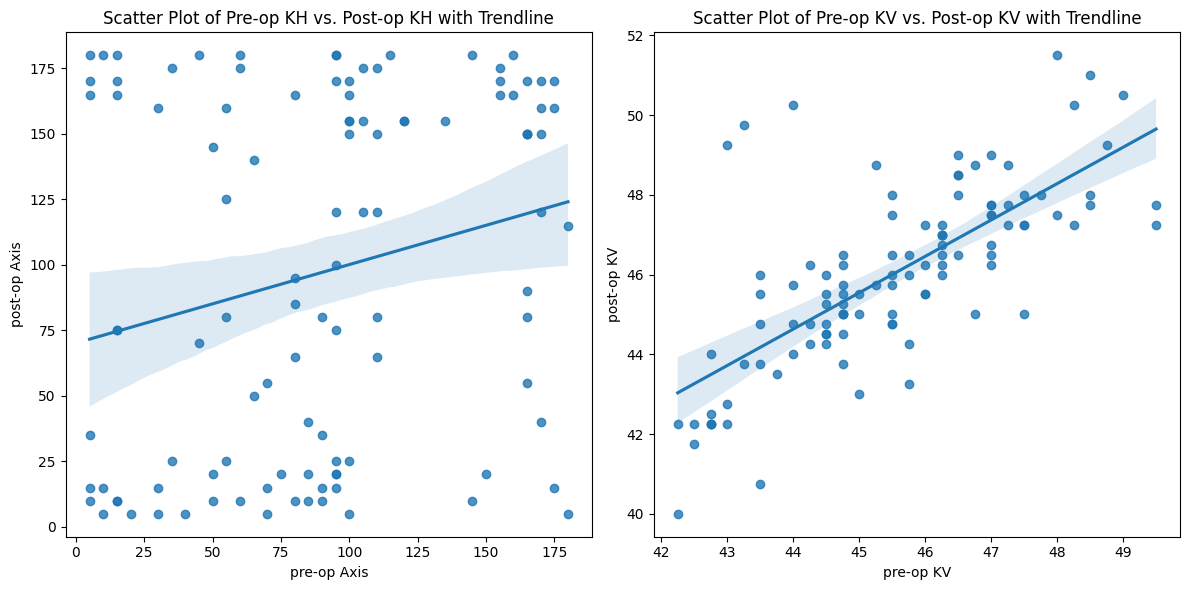

In [69]:
# prompt: Scatter plots trendline side by side

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.regplot(x='pre-op Axis', y='post-op Axis', data=df, ax=axes[0])
axes[0].set_title('Scatter Plot of Pre-op KH vs. Post-op KH with Trendline')

sns.regplot(x='pre-op KV', y='post-op KV', data=df, ax=axes[1])
axes[1].set_title('Scatter Plot of Pre-op KV vs. Post-op KV with Trendline')

plt.tight_layout()
plt.show()

In [70]:
# prompt: SIA magnitude and axis based on Pythagorean

import numpy as np
# Calculate SIA based on the change in K values
df['SIA KH'] = df['post-op KH'] - df['pre-op KH']
df['SIA KV'] = df['post-op KV'] - df['pre-op KV']

# Calculate the magnitude of SIA using Pythagorean theorem
df['SIA Magnitude'] = np.sqrt(df['SIA KH']**2 + df['SIA KV']**2)

# Calculate the axis of SIA using arctan2
df['SIA Axis'] = np.arctan2(df['SIA KV'], df['SIA KH']) * (180/np.pi)

# Adjust the axis to be between 0 and 180 degrees if needed (depending on how you want to represent axis)
# A common convention is to represent the steepest meridian, which can be between 0 and 180.
# The direction of the change also matters. arctan2 gives direction.
# If you want the axis of the astigmatism change, this would be different.
# For simplicity here, SIA Axis represents the direction of the vector change in K values.

# If you need the axis of the astigmatism itself (as in cylinder axis),
# you would typically use the difference in refractive error vectors.
# The calculation of SIA magnitude and axis from K readings can be complex
# and depends on the specific clinical definition of SIA being used.
# The above calculates the magnitude and axis of the vector difference between post-op and pre-op K readings.

# Display the new columns
print(df[['pre-op KH', 'post-op KH', 'SIA KH', 'pre-op KV', 'post-op KV', 'SIA KV', 'SIA Magnitude', 'SIA Axis']].head())

   pre-op KH  post-op KH  SIA KH  pre-op KV  post-op KV  SIA KV  \
0      43.50       43.25   -0.25      44.00       44.75    0.75   
1      44.25       41.25   -3.00      44.50       44.50    0.00   
2      47.75       46.00   -1.75      49.50       47.75   -1.75   
3      43.75       42.75   -1.00      44.75       45.00    0.25   
4      44.25       44.50    0.25      44.75       45.50    0.75   

   SIA Magnitude    SIA Axis  
0       0.790569  108.434949  
1       3.000000  180.000000  
2       2.474874 -135.000000  
3       1.030776  165.963757  
4       0.790569   71.565051  


     SIA Axis  SIA Axis Adjusted
0  108.434949         108.434949
1  180.000000         180.000000
2 -135.000000          45.000000
3  165.963757         165.963757
4   71.565051          71.565051


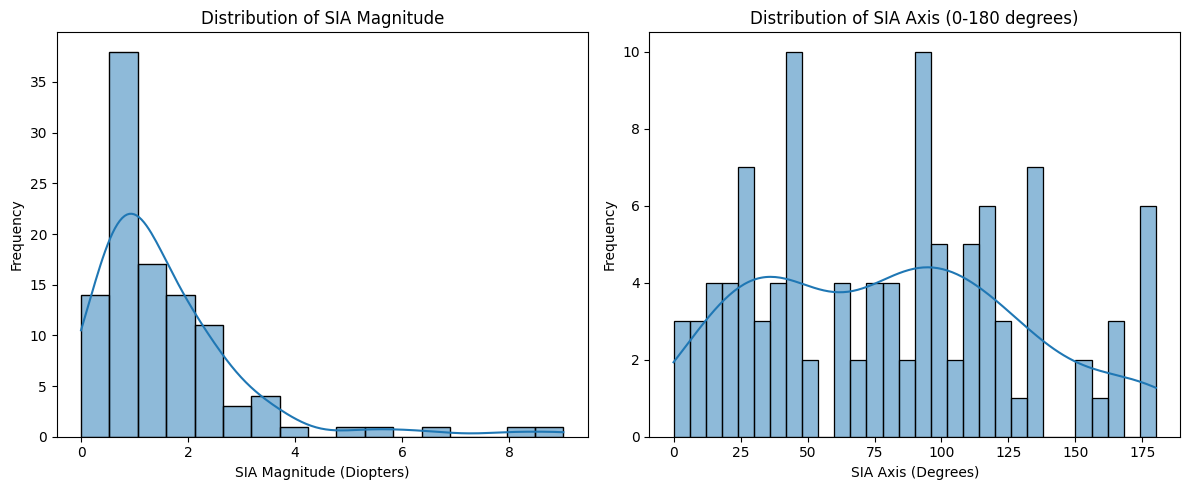

In [71]:
# prompt: Quadrantic hadling

import matplotlib.pyplot as plt
# Function to handle quadrantic values for SIA Axis
def handle_quadratic_axis(axis):
  # Ensure axis is between 0 and 360
  axis = axis % 360
  # Map to 0-180 range. This is a common approach for representing astigmatism axis,
  # where an axis of X is equivalent to X + 180.
  # However, SIA axis interpretation from K values is more nuanced and depends on definition.
  # This simple mapping assumes we just want the principal meridian angle between 0 and 180.
  if axis > 180:
    return axis - 180
  return axis

# Apply the function to the 'SIA Axis' column
# Note: The interpretation of SIA axis from K values is not universally standardized
# and this simple mapping might not align with specific clinical definitions.
# For a more robust SIA analysis (like using vector analysis plots - Alpins method),
# you would need to calculate the astigmatic vector components (J0, J45) from K values.
# This code provides a basic handling based on the previously calculated arctan2 axis.
df['SIA Axis Adjusted'] = df['SIA Axis'].apply(handle_quadratic_axis)

print(df[['SIA Axis', 'SIA Axis Adjusted']].head())

# You might want to visualize the distribution of SIA Magnitude and Axis
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='SIA Magnitude', kde=True)
plt.title('Distribution of SIA Magnitude')
plt.xlabel('SIA Magnitude (Diopters)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
# Plotting the adjusted axis between 0 and 180
sns.histplot(data=df, x='SIA Axis Adjusted', bins=30, kde=True)
plt.title('Distribution of SIA Axis (0-180 degrees)')
plt.xlabel('SIA Axis (Degrees)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Further analysis like vector analysis (Alpins method) would require calculating
# vector components (e.g., using the EyeSuite standard) and plotting centroid and ellipse.
# This requires converting K values to power vectors.
# The formula for converting K values (K1, Axis1, K2, Axis2) to J0 and J45 components is:
# J0 = -(C/2) * cos(2 * Axis)
# J45 = -(C/2) * sin(2 * Axis)
# Where C is the magnitude of the astigmatism (K1 - K2) and Axis is the axis of the flatter meridian.
# This is more complex when dealing with pre and post-op changes.
# A common method for SIA is to calculate the difference vector between post-op and pre-op power vectors.
# This code focuses on the magnitude and axis of the K-value difference vector.

In [72]:
df

,pre-op KH,pre-op KV,pre-op Axis,post-op KH,post-op KV,post-op Axis,SIA KH,SIA KV,SIA Magnitude,SIA Axis,SIA Axis Adjusted
0,43.50,44.00,90,43.25,44.75,10,-0.25,0.75,0.790569,108.434949,108.434949
1,44.25,44.50,45,41.25,44.50,70,-3.00,0.00,3.000000,180.000000,180.000000
2,47.75,49.50,5,46.00,47.75,35,-1.75,-1.75,2.474874,-135.000000,45.000000
3,43.75,44.75,165,42.75,45.00,150,-1.00,0.25,1.030776,165.963757,165.963757
4,44.25,44.75,85,44.50,45.50,40,0.25,0.75,0.790569,71.565051,71.565051
...,...,...,...,...,...,...,...,...,...,...,...
102,43.00,43.50,100,43.00,43.75,170,0.00,0.25,0.250000,90.000000,90.000000
103,45.75,46.25,30,45.75,47.00,5,0.00,0.75,0.750000,90.000000,90.000000
104,45.25,46.00,135,44.25,45.50,155,-1.00,-0.50,1.118034,-153.434949,26.565051
105,46.00,46.50,40,46.25,48.00,5,0.25,1.50,1.520691,80.537678,80.537678


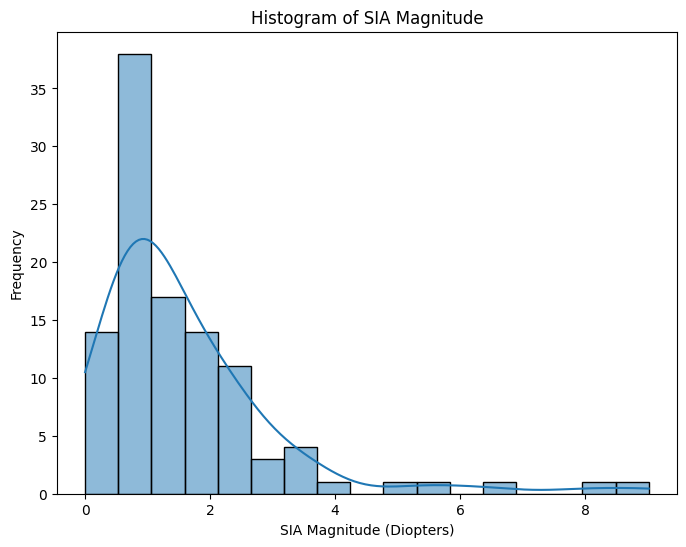

In [73]:
# prompt: SIA magnitude histogram

import matplotlib.pyplot as plt
# Select the column for histogram
col_to_hist = 'SIA Magnitude'

# Create histogram for SIA Magnitude
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x=col_to_hist, kde=True)
plt.title(f'Histogram of {col_to_hist}')
plt.xlabel('SIA Magnitude (Diopters)')
plt.ylabel('Frequency')
plt.show()

Original number of rows: 107
Number of rows after outlier removal: 102


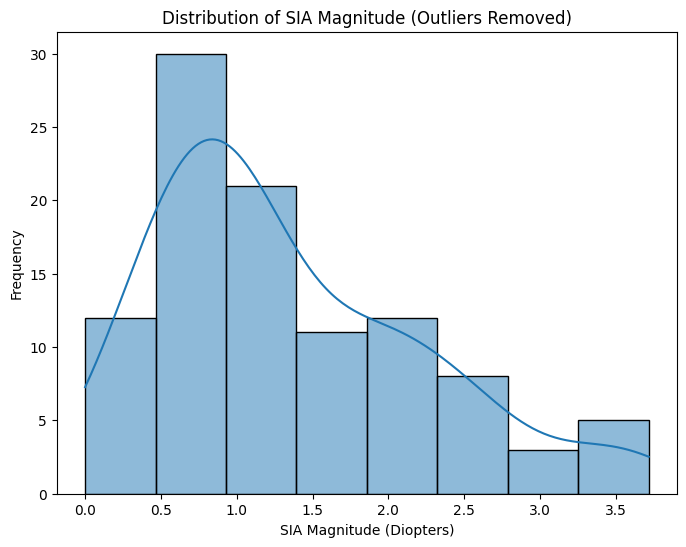

In [74]:
# prompt: Remove outliers In sia magnitude

import matplotlib.pyplot as plt
# Remove outliers using the IQR method for 'SIA Magnitude'
Q1 = df['SIA Magnitude'].quantile(0.25)
Q3 = df['SIA Magnitude'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
df_filtered = df[(df['SIA Magnitude'] >= lower_bound) & (df['SIA Magnitude'] <= upper_bound)].copy()

print(f"Original number of rows: {len(df)}")
print(f"Number of rows after outlier removal: {len(df_filtered)}")

# Optional: Visualize the distribution after outlier removal
plt.figure(figsize=(8, 6))
sns.histplot(data=df_filtered, x='SIA Magnitude', kde=True)
plt.title('Distribution of SIA Magnitude (Outliers Removed)')
plt.xlabel('SIA Magnitude (Diopters)')
plt.ylabel('Frequency')
plt.show()

# You can now use df_filtered for further analysis


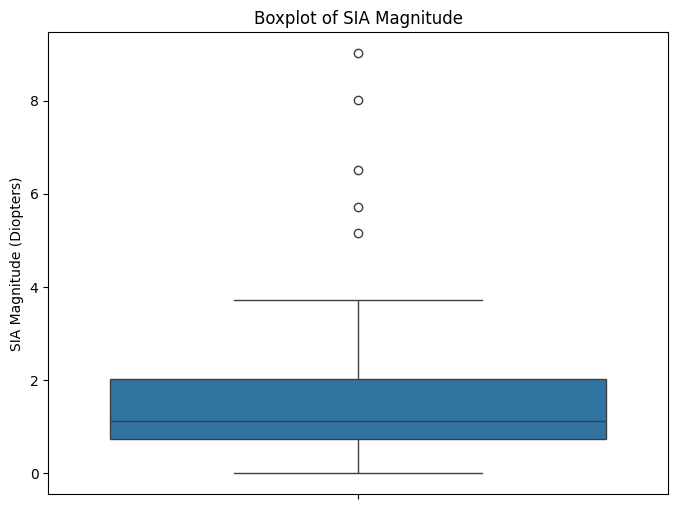

In [75]:
# prompt: SIA magnitude boxplot

import matplotlib.pyplot as plt
# Create a boxplot for SIA Magnitude
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='SIA Magnitude')
plt.title('Boxplot of SIA Magnitude')
plt.ylabel('SIA Magnitude (Diopters)')
plt.show()

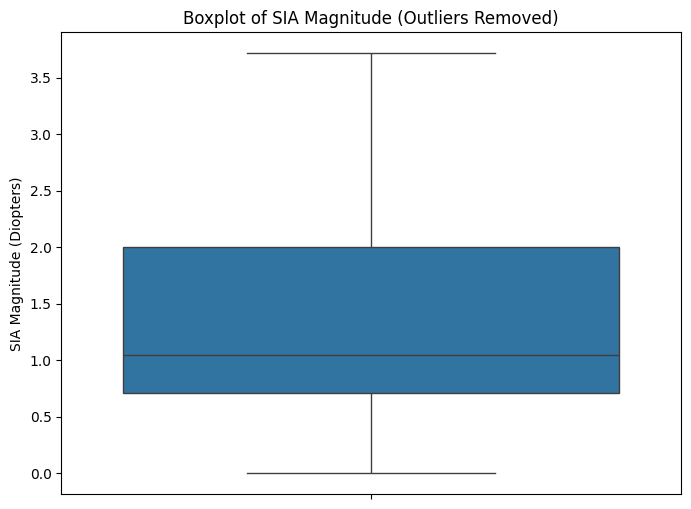

In [76]:
# prompt: SIA magnitude df_filtered boxplot

import matplotlib.pyplot as plt
# Create a boxplot for SIA Magnitude on the filtered DataFrame
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_filtered, y='SIA Magnitude')
plt.title('Boxplot of SIA Magnitude (Outliers Removed)')
plt.ylabel('SIA Magnitude (Diopters)')
plt.show()

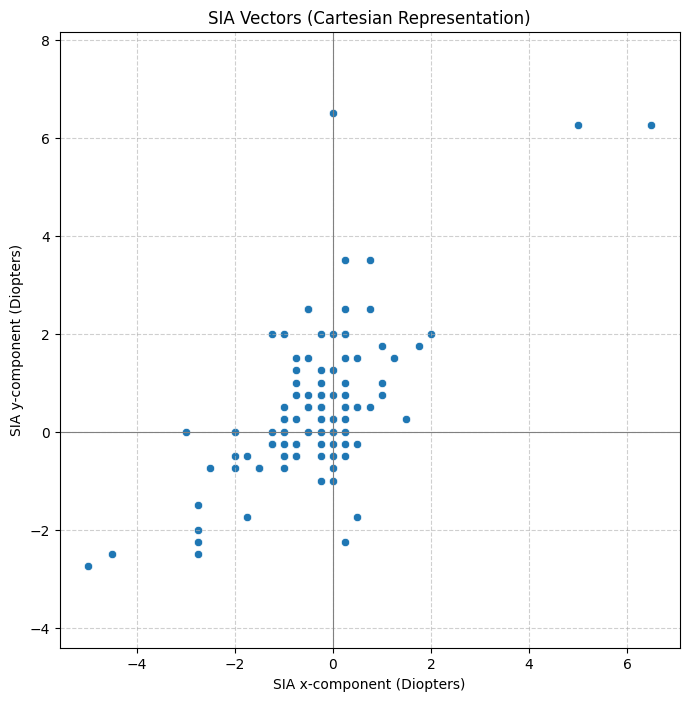

Mean SIA Vector (Cartesian): (-0.37, 0.50)
Mean SIA Vector (Polar): Magnitude=0.62 D, Axis=126.57°


In [77]:
# prompt: SIA vector

import matplotlib.pyplot as plt
import numpy as np
# Convert SIA Magnitude and SIA Axis Adjusted to vectors
# This is a representation of the SIA vector in polar coordinates.
# To perform true vector analysis (like plotting centroid and ellipse),
# you would typically convert to Cartesian power vectors (J0, J45).

# For a simplified visualization of the distribution of the SIA vector
# in a polar plot, you can use the magnitude and angle.
# We need to adjust the axis for plotting, as cartesian coordinates for polar
# plots usually expect radians and 0-360 or -180 to 180.
# The 'SIA Axis Adjusted' is 0-180, which is suitable for showing the axis direction,
# but for plotting a vector, you might use the original 'SIA Axis' which includes direction.

# Let's plot the SIA vectors using a scatter plot on Cartesian plane
# where x = magnitude * cos(axis) and y = magnitude * sin(axis)
# We will use the original SIA Axis (in degrees) for direction, converting to radians.

df['SIA_x'] = df['SIA Magnitude'] * np.cos(np.deg2rad(df['SIA Axis']))
df['SIA_y'] = df['SIA Magnitude'] * np.sin(np.deg2rad(df['SIA Axis']))

# Plot the SIA vectors as points on a scatter plot
plt.figure(figsize=(8, 8))
sns.scatterplot(x='SIA_x', y='SIA_y', data=df)
plt.axhline(0, color='grey', lw=0.8)
plt.axvline(0, color='grey', lw=0.8)
plt.xlabel('SIA x-component (Diopters)')
plt.ylabel('SIA y-component (Diopters)')
plt.title('SIA Vectors (Cartesian Representation)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal') # Ensures that the scale is the same on both axes
plt.show()

# To get the mean SIA vector (centroid), calculate the mean of the x and y components
mean_sia_x = df['SIA_x'].mean()
mean_sia_y = df['SIA_y'].mean()

# Calculate the magnitude and axis of the mean SIA vector
mean_sia_magnitude = np.sqrt(mean_sia_x**2 + mean_sia_y**2)
mean_sia_axis_rad = np.arctan2(mean_sia_y, mean_sia_x)
mean_sia_axis_deg = np.rad2deg(mean_sia_axis_rad)

print(f"Mean SIA Vector (Cartesian): ({mean_sia_x:.2f}, {mean_sia_y:.2f})")
print(f"Mean SIA Vector (Polar): Magnitude={mean_sia_magnitude:.2f} D, Axis={mean_sia_axis_deg:.2f}°")

# Note: A proper vector analysis plot (like a double-angle vector plot)
# would require converting K values to power vectors (J0, J45) and plotting
# the difference vectors. The above is a simplified representation of the
# K-difference vector.

In [78]:
# prompt: SIA vector for single patient

import numpy as np
# Function to calculate SIA vector for a single patient
def calculate_sia_vector(pre_op_kh, post_op_kh, pre_op_kv, post_op_kv):
  """
  Calculates the SIA vector (magnitude and axis) for a single patient
  based on changes in keratometry values (KH and KV).

  Args:
    pre_op_kh (float): Pre-operative Keratometry reading (Horizontal).
    post_op_kh (float): Post-operative Keratometry reading (Horizontal).
    pre_op_kv (float): Pre-operative Keratometry reading (Vertical).
    post_op_kv (float): Post-operative Keratometry reading (Vertical).

  Returns:
    tuple: A tuple containing:
      - sia_magnitude (float): The magnitude of the SIA vector in Diopters.
      - sia_axis (float): The axis of the SIA vector in degrees (ranging from -180 to 180).
  """
  sia_kh = post_op_kh - pre_op_kh
  sia_kv = post_op_kv - pre_op_kv

  # Calculate the magnitude of SIA using Pythagorean theorem
  sia_magnitude = np.sqrt(sia_kh**2 + sia_kv**2)

  # Calculate the axis of SIA using arctan2
  # arctan2 gives the angle in radians, ranging from -pi to pi.
  # Convert to degrees and then map to -180 to 180.
  sia_axis_rad = np.arctan2(sia_kv, sia_kh)
  sia_axis_deg = np.rad2deg(sia_axis_rad)

  return sia_magnitude, sia_axis_deg

# Example usage for the first patient in the dataframe:
if not df.empty:
  first_patient = df.iloc[0]
  pre_op_kh = first_patient['pre-op KH']
  post_op_kh = first_patient['post-op KH']
  pre_op_kv = first_patient['pre-op KV']
  post_op_kv = first_patient['post-op KV']

  sia_magnitude_single, sia_axis_single = calculate_sia_vector(
      pre_op_kh, post_op_kh, pre_op_kv, post_op_kv
  )

  print(f"\nSIA Vector for the first patient:")
  print(f"  Magnitude: {sia_magnitude_single:.2f} D")
  print(f"  Axis: {sia_axis_single:.2f}°")
else:
  print("DataFrame is empty. Cannot calculate SIA for a single patient.")



SIA Vector for the first patient:
  Magnitude: 0.79 D
  Axis: 108.43°


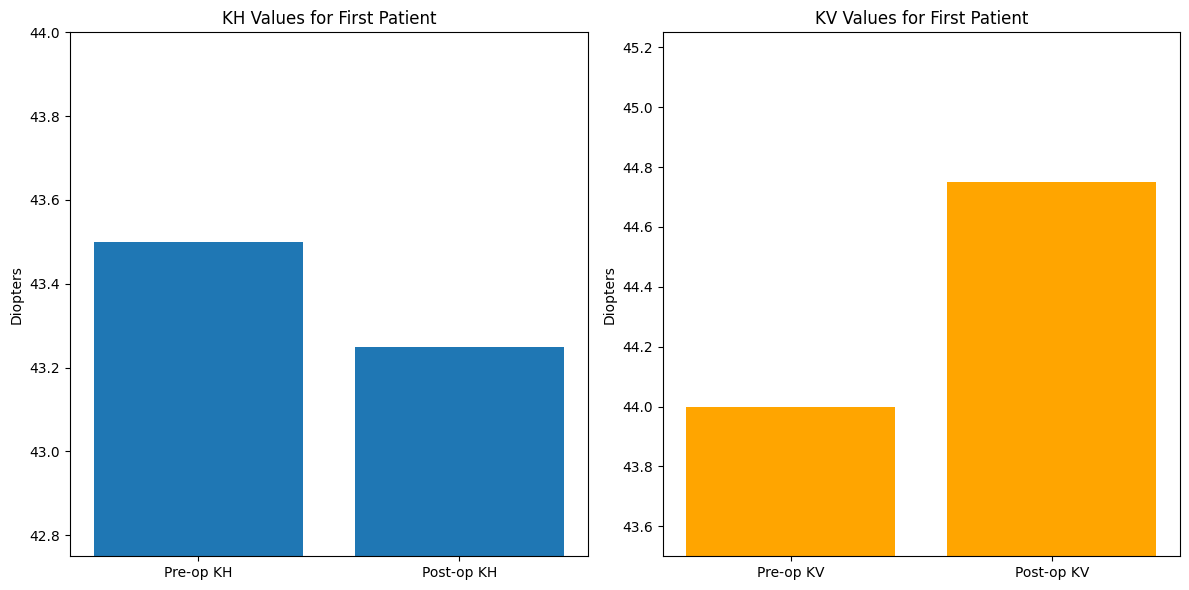

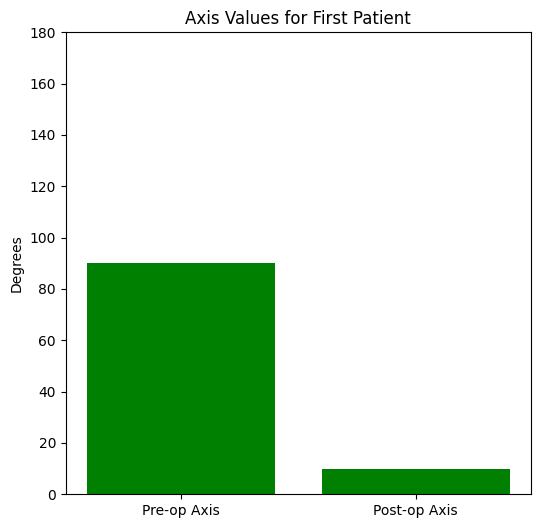


SIA Vector for the first patient:
  Magnitude: 0.79 D
  Axis: 108.43°


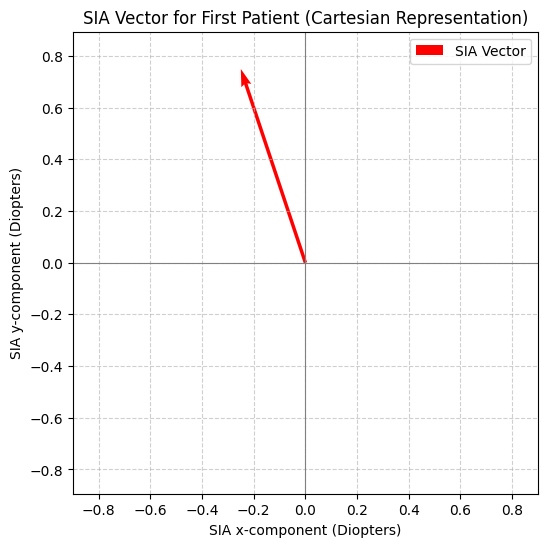

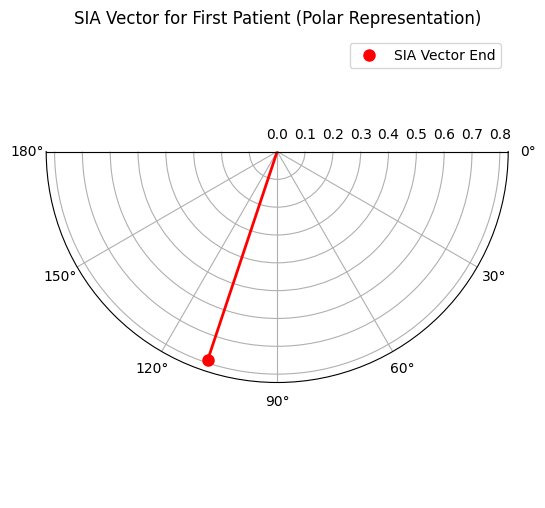

In [79]:
# prompt: Plot for the first patient

import matplotlib.pyplot as plt
import numpy as np
# Select the data for the first patient
first_patient_data = df.iloc[[0]]

# Create a figure and axes for plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the pre-op and post-op KH values for the first patient
axes[0].bar(['Pre-op KH', 'Post-op KH'], [first_patient_data['pre-op KH'].iloc[0], first_patient_data['post-op KH'].iloc[0]])
axes[0].set_title('KH Values for First Patient')
axes[0].set_ylabel('Diopters')
axes[0].set_ylim(min(first_patient_data[['pre-op KH', 'post-op KH']].min()) - 0.5, max(first_patient_data[['pre-op KH', 'post-op KH']].max()) + 0.5)


# Plot the pre-op and post-op KV values for the first patient
axes[1].bar(['Pre-op KV', 'Post-op KV'], [first_patient_data['pre-op KV'].iloc[0], first_patient_data['post-op KV'].iloc[0]], color='orange')
axes[1].set_title('KV Values for First Patient')
axes[1].set_ylabel('Diopters')
axes[1].set_ylim(min(first_patient_data[['pre-op KV', 'post-op KV']].min()) - 0.5, max(first_patient_data[['pre-op KV', 'post-op KV']].max()) + 0.5)


plt.tight_layout()
plt.show()

# Plot the pre-op and post-op Axis values for the first patient
plt.figure(figsize=(6, 6))
plt.bar(['Pre-op Axis', 'Post-op Axis'], [first_patient_data['pre-op Axis'].iloc[0], first_patient_data['post-op Axis'].iloc[0]], color='green')
plt.title('Axis Values for First Patient')
plt.ylabel('Degrees')
plt.ylim(0, 180) # Axis is typically represented between 0 and 180 degrees
plt.show()


# Calculate SIA magnitude and axis for the first patient (already done above, just using the variables)
print(f"\nSIA Vector for the first patient:")
print(f"  Magnitude: {sia_magnitude_single:.2f} D")
print(f"  Axis: {sia_axis_single:.2f}°")

# Plot the SIA vector for the first patient on a Cartesian plane
plt.figure(figsize=(6, 6))
plt.quiver(0, 0, first_patient_data['SIA_x'].iloc[0], first_patient_data['SIA_y'].iloc[0],
           angles='xy', scale_units='xy', scale=1, color='red', label='SIA Vector')
plt.axhline(0, color='grey', lw=0.8)
plt.axvline(0, color='grey', lw=0.8)
plt.xlabel('SIA x-component (Diopters)')
plt.ylabel('SIA y-component (Diopters)')
plt.title('SIA Vector for First Patient (Cartesian Representation)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')
# Adjust plot limits to make the vector visible
max_abs = max(abs(first_patient_data['SIA_x'].iloc[0]), abs(first_patient_data['SIA_y'].iloc[0]), 0.5) # ensure at least 0.5 range
plt.xlim(-max_abs * 1.2, max_abs * 1.2)
plt.ylim(-max_abs * 1.2, max_abs * 1.2)
plt.show()

# Optional: Plot the SIA vector for the first patient in a polar plot
# This requires plotting magnitude at the specific angle.
# matplotlib's polar plot works with radians.
plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection='polar')

# Plot a dot at the end of the vector
ax.plot(np.deg2rad(sia_axis_single), sia_magnitude_single, 'ro', markersize=8, label='SIA Vector End')
# Plot the vector line from the origin
ax.plot([0, np.deg2rad(sia_axis_single)], [0, sia_magnitude_single], 'r-', linewidth=2)

ax.set_theta_zero_location("E") # Set 0 degrees to the right (standard for ophthalmology)
ax.set_theta_direction(-1)     # Go clockwise (standard for ophthalmology axis)
ax.set_thetalim(0, np.pi)       # Limit angles to 0-180 degrees for axis representation
ax.set_rlabel_position(0)
ax.set_title('SIA Vector for First Patient (Polar Representation)', va='bottom')
ax.legend()
plt.show()


SIA Vectors for the first 5 patients:

Patient 1:
  Magnitude: 0.79 D
  Axis: 108.43°

Patient 2:
  Magnitude: 3.00 D
  Axis: 180.00°

Patient 3:
  Magnitude: 2.47 D
  Axis: -135.00°

Patient 4:
  Magnitude: 1.03 D
  Axis: 165.96°

Patient 5:
  Magnitude: 0.79 D
  Axis: 71.57°


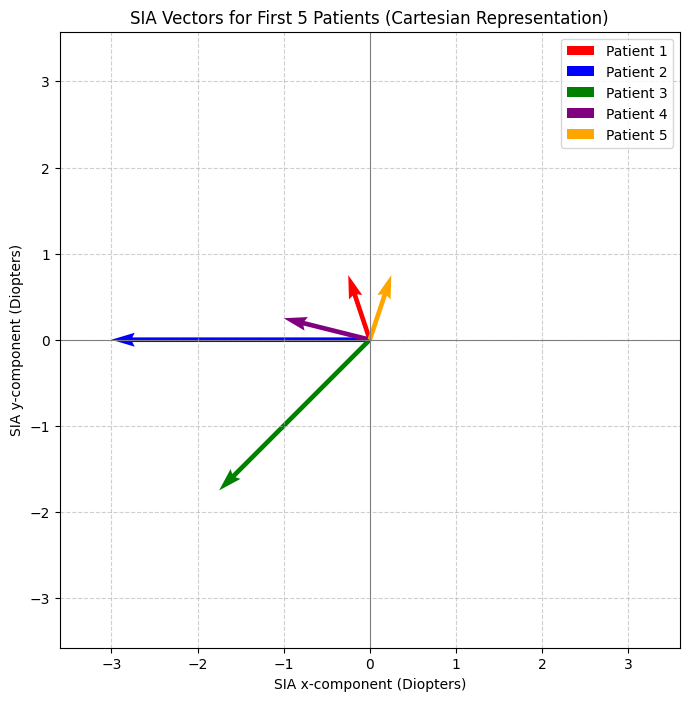

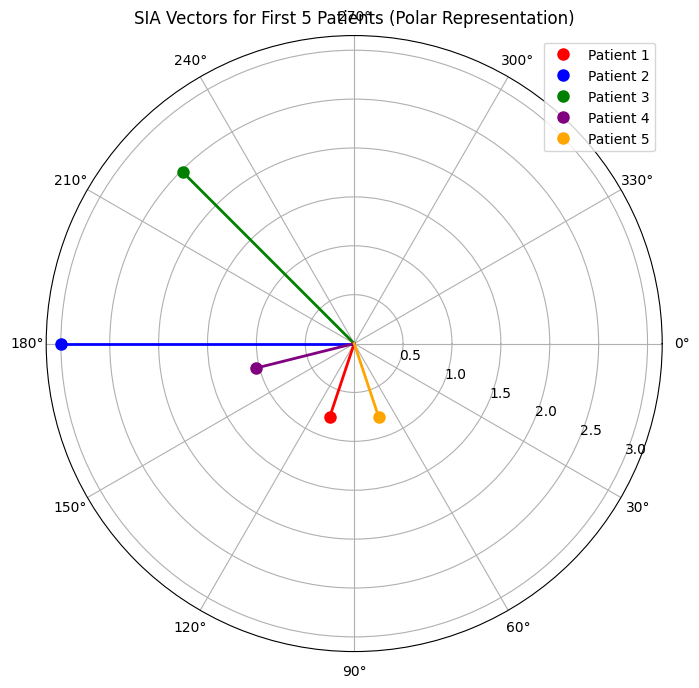

In [80]:
# prompt: For 5 patients

import matplotlib.pyplot as plt
import numpy as np
# Select the data for the first 5 patients
first_5_patients_data = df.head(5).copy()

# Iterate through the first 5 patients and calculate/print their SIA vectors
print("\nSIA Vectors for the first 5 patients:")
for index, row in first_5_patients_data.iterrows():
  pre_op_kh = row['pre-op KH']
  post_op_kh = row['post-op KH']
  pre_op_kv = row['pre-op KV']
  post_op_kv = row['post-op KV']

  sia_magnitude, sia_axis = calculate_sia_vector(
      pre_op_kh, post_op_kh, pre_op_kv, post_op_kv
  )

  patient_number = index + 1 # Assuming index starts at 0 for the first patient
  print(f"\nPatient {patient_number}:")
  print(f"  Magnitude: {sia_magnitude:.2f} D")
  print(f"  Axis: {sia_axis:.2f}°")

# Plot the SIA vectors for the first 5 patients on a single Cartesian plane
plt.figure(figsize=(8, 8))
colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(len(first_5_patients_data)):
    patient_data = first_5_patients_data.iloc[i]
    plt.quiver(0, 0, patient_data['SIA_x'], patient_data['SIA_y'],
               angles='xy', scale_units='xy', scale=1, color=colors[i],
               label=f'Patient {i+1}')

plt.axhline(0, color='grey', lw=0.8)
plt.axvline(0, color='grey', lw=0.8)
plt.xlabel('SIA x-component (Diopters)')
plt.ylabel('SIA y-component (Diopters)')
plt.title('SIA Vectors for First 5 Patients (Cartesian Representation)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')
# Adjust plot limits based on the range of the first 5 patients' vectors
max_abs_5 = max(abs(first_5_patients_data['SIA_x']).max(), abs(first_5_patients_data['SIA_y']).max(), 0.5)
plt.xlim(-max_abs_5 * 1.2, max_abs_5 * 1.2)
plt.ylim(-max_abs_5 * 1.2, max_abs_5 * 1.2)
plt.show()

# Plot the SIA vectors for the first 5 patients in a polar plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, projection='polar')

for i in range(len(first_5_patients_data)):
    patient_data = first_5_patients_data.iloc[i]
    # Convert the axis from -180 to 180 range (output of calculate_sia_vector) to 0-360 for polar plot
    # Or you might map it to 0-180 if you only care about the meridian axis.
    # Let's use the original SIA Axis which includes the direction, mapped to 0-360 for polar plotting.
    plot_axis_deg = patient_data['SIA Axis']
    if plot_axis_deg < 0:
        plot_axis_deg += 360

    ax.plot(np.deg2rad(plot_axis_deg), patient_data['SIA Magnitude'], 'o',
            color=colors[i], markersize=8, label=f'Patient {i+1}')
    ax.plot([0, np.deg2rad(plot_axis_deg)], [0, patient_data['SIA Magnitude']], '-',
            color=colors[i], linewidth=2)


ax.set_theta_zero_location("E") # Set 0 degrees to the right
ax.set_theta_direction(-1)     # Go clockwise
# Adjust theta ticks to be every 30 degrees for clarity in ophthalmology context
ax.set_xticks(np.deg2rad(np.arange(0, 360, 30)))
ax.set_thetalim(0, np.deg2rad(360)) # Show the full 360 circle

ax.set_title('SIA Vectors for First 5 Patients (Polar Representation)', va='bottom')
ax.legend()
plt.show()

Centroid of SIA Vectors (Cartesian): (-0.37, 0.50)


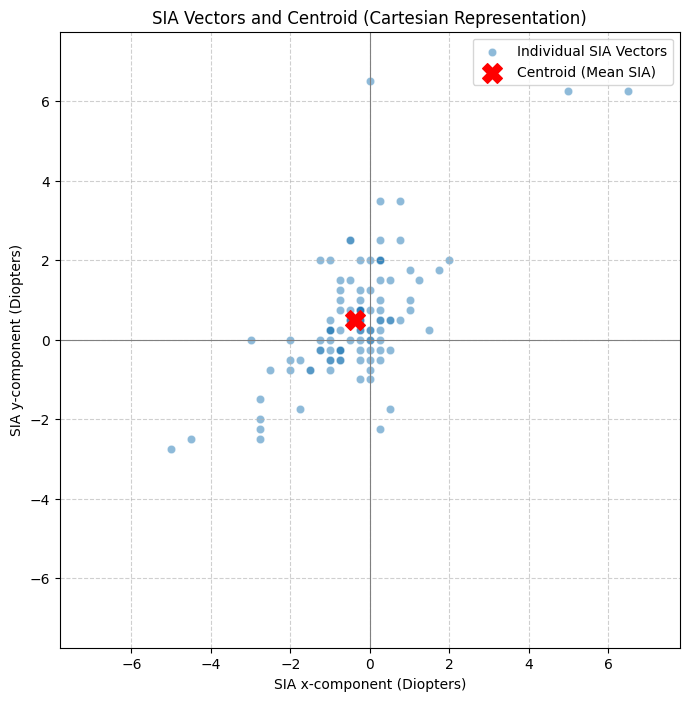

Centroid of SIA Vectors (Polar): Magnitude=0.62 D, Axis=126.57°


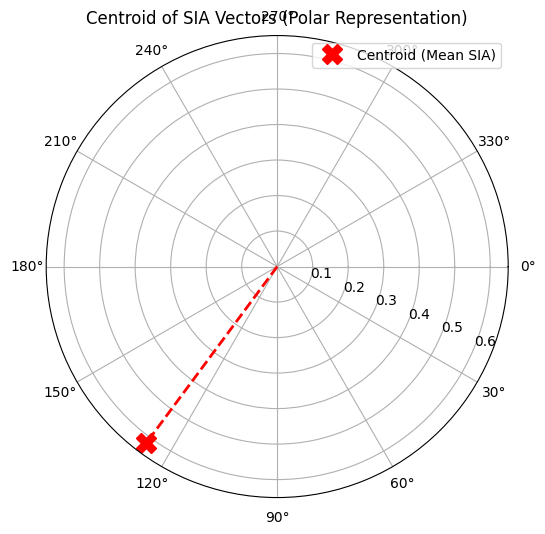

In [81]:
# prompt: Centroid

import matplotlib.pyplot as plt
import numpy as np
# Calculate the centroid (mean) of the SIA vectors
mean_sia_x = df['SIA_x'].mean()
mean_sia_y = df['SIA_y'].mean()

print(f"Centroid of SIA Vectors (Cartesian): ({mean_sia_x:.2f}, {mean_sia_y:.2f})")

# Plot the SIA vectors and the centroid
plt.figure(figsize=(8, 8))
sns.scatterplot(x='SIA_x', y='SIA_y', data=df, label='Individual SIA Vectors', alpha=0.5)
plt.scatter(mean_sia_x, mean_sia_y, color='red', marker='X', s=200, label='Centroid (Mean SIA)')

plt.axhline(0, color='grey', lw=0.8)
plt.axvline(0, color='grey', lw=0.8)
plt.xlabel('SIA x-component (Diopters)')
plt.ylabel('SIA y-component (Diopters)')
plt.title('SIA Vectors and Centroid (Cartesian Representation)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')
# Adjust plot limits to encompass all points and the centroid
max_x = max(abs(df['SIA_x']).max(), abs(mean_sia_x), 0.5)
max_y = max(abs(df['SIA_y']).max(), abs(mean_sia_y), 0.5)
max_limit = max(max_x, max_y) * 1.2

plt.xlim(-max_limit, max_limit)
plt.ylim(-max_limit, max_limit)
plt.show()

# To represent the centroid in a polar plot, calculate its magnitude and axis
mean_sia_magnitude = np.sqrt(mean_sia_x**2 + mean_sia_y**2)
mean_sia_axis_rad = np.arctan2(mean_sia_y, mean_sia_x)
mean_sia_axis_deg = np.rad2deg(mean_sia_axis_rad)

# Adjust the mean axis for polar plotting (e.g., 0-360)
mean_plot_axis_deg = mean_sia_axis_deg
if mean_plot_axis_deg < 0:
    mean_plot_axis_deg += 360


print(f"Centroid of SIA Vectors (Polar): Magnitude={mean_sia_magnitude:.2f} D, Axis={mean_sia_axis_deg:.2f}°")


# Plot the centroid on a polar plot
plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection='polar')

# Plot the centroid as a point
ax.plot(np.deg2rad(mean_plot_axis_deg), mean_sia_magnitude, 'rX', markersize=15, label='Centroid (Mean SIA)')

# Optional: Plot a vector line for the centroid
ax.plot([0, np.deg2rad(mean_plot_axis_deg)], [0, mean_sia_magnitude], 'r--', linewidth=2)

ax.set_theta_zero_location("E") # Set 0 degrees to the right
ax.set_theta_direction(-1)     # Go clockwise
ax.set_xticks(np.deg2rad(np.arange(0, 360, 30)))
ax.set_thetalim(0, np.deg2rad(360)) # Show the full 360 circle

ax.set_title('Centroid of SIA Vectors (Polar Representation)', va='bottom')
ax.legend()
plt.show()



Centroid of SIA Vectors (J0, J45): (-0.53, 0.03)


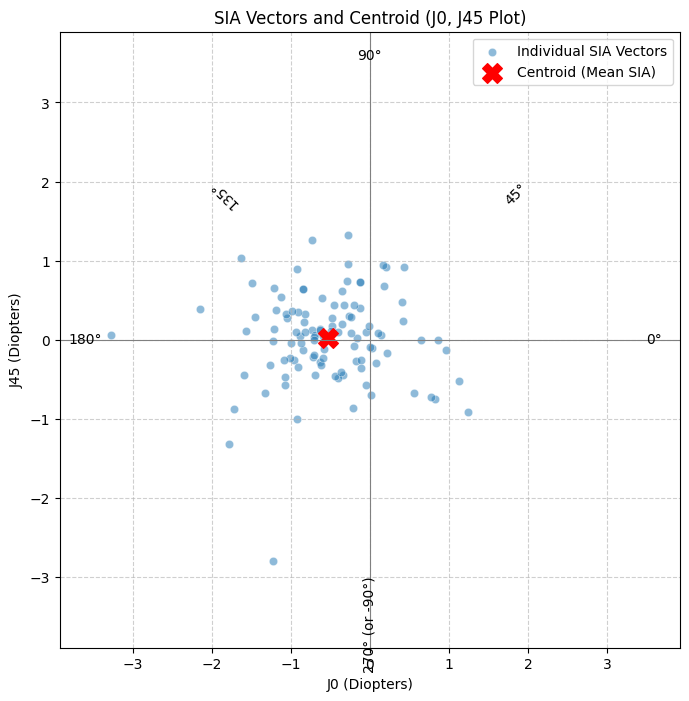


Centroid (Mean SIA):
  Astigmatism Magnitude: 1.05 D
  Astigmatism Axis: 88.48°


In [82]:
# prompt: Centroid plot

import matplotlib.pyplot as plt
import numpy as np
# Centroid Plot using J0, J45 vectors (Standard Ophthalmological Practice)

# To get a standard centroid plot (like Alpins vector analysis),
# we need to convert K values to power vectors (J0, J45) and then
# calculate the difference vectors.

# Formulas to convert (K1, Axis1, K2, Axis2) to (J0, J45) where K1 and K2 are
# the two principal keratometry readings and Axis1 is the axis of K1.
# It's more common to use the flatter K (Kf) and steeper K (Ks) and the axis of the flatter K (Axis_f).
# The astigmatism magnitude is C = Ks - Kf.
# J0 = - (C/2) * cos(2 * Axis_f)
# J45 = - (C/2) * sin(2 * Axis_f)

# However, your data provides pre-op KH, KV and post-op KH, KV, and their axes.
# A simpler approach given your data structure is to assume KH is at 0 degrees
# and KV is at 90 degrees for the purpose of vector calculation from K readings.
# This is a simplification and might not represent the true astigmatic vector
# if the principal meridians are not exactly 0 and 90.

# Let's calculate J0 and J45 based on the assumption that KH is at 0 and KV is at 90.
# Pre-op:
# Astigmatism magnitude = abs(pre-op KH - pre-op KV)
# If pre-op KH > pre-op KV, the "flatter" K is pre-op KV (at 90 deg), "steeper" is pre-op KH (at 0 deg).
# If pre-op KV > pre-op KH, the "flatter" K is pre-op KH (at 0 deg), "steeper" is pre-op KV (at 90 deg).

# This method doesn't directly use the 'pre-op Axis' and 'post-op Axis' columns
# which represent the axis of astigmatism itself, but rather calculates the J0/J45
# components based on the K values at 0 and 90 degrees.

# A more accurate approach if 'pre-op Axis' is the axis of the steeper meridian (or flatter)
# and the astigmatism magnitude is derived from KH and KV:

# Let's assume for simplicity that 'pre-op Axis' is the axis of the flatter meridian
# and the astigmatism magnitude is |pre-op KH - pre-op KV|. This is also a simplification.

# The standard way is to convert the K readings into a power vector (J0, J45).
# Given (K1, Axis1), (K2, Axis2) where K1 and K2 are principal powers at Axis1 and Axis2 (separated by 90 degrees):
# Mean K = (K1 + K2) / 2
# C = K2 - K1 (assuming K2 is steeper than K1) or abs(K1 - K2) for magnitude
# Axis = Axis1 (if K1 is flatter) or Axis2 (if K2 is flatter).
# J0 = -(C/2) * cos(2 * Axis)
# J45 = -(C/2) * sin(2 * Axis)

# Your data has KH and KV and a single 'Axis' column. Let's assume 'Axis' is the axis of the steeper meridian.
# Then the magnitude of astigmatism is |KH - KV|.
# If KH > KV, steeper is KH at its axis (let's assume 0). If KV > KH, steeper is KV at its axis (let's assume 90).
# This still leads back to assumptions about the relationship between KH, KV, and the 'Axis' column.

# Let's try calculating J0 and J45 based on the difference vector using the method from the previous cell:
# SIA_x = SIA Magnitude * cos(SIA Axis)
# SIA_y = SIA Magnitude * sin(SIA Axis)

# In standard vector analysis, the vector components are J0 and J45.
# A vector (Vx, Vy) can be represented as:
# Magnitude = sqrt(Vx^2 + Vy^2)
# Angle = arctan2(Vy, Vx)
# For astigmatism vectors (J0, J45):
# Magnitude = sqrt(J0^2 + J45^2) * 2  (Astigmatism magnitude = 2 * Vector Magnitude)
# Axis = 0.5 * arctan2(J45, J0)

# Let's redefine the vector components based on standard J0/J45.
# This requires calculating pre-op and post-op J0/J45 vectors first.

# Assuming KH is K at 0 degrees and KV is K at 90 degrees.
# Pre-op J0 = -( (pre-op KH - pre-op KV)/2 ) * cos(2 * 0)  # Simplified for this assumption
# Pre-op J45 = -( (pre-op KH - pre-op KV)/2 ) * sin(2 * 0) # This would make J45 always 0

# This assumption is likely incorrect if 'pre-op Axis' is the actual axis of astigmatism.
# A more appropriate approach is to use the astigmatism magnitude (derived from KH/KV or other means)
# and the 'Axis' column to calculate J0 and J45 for pre-op and post-op states.

# Let's assume astigmatism magnitude is abs(KH - KV) and the 'Axis' column is the axis of the steeper meridian.
# This is still an assumption based on common ophthalmological data, but might not be precisely how your data is structured.

# Recalculate J0 and J45 for pre-op and post-op based on assumed magnitude |KH-KV| and Axis column
# Function to calculate J0 and J45 from magnitude and axis (in degrees)
def calculate_j0_j45(magnitude, axis_deg):
    """
    Calculates J0 and J45 vector components from astigmatism magnitude and axis.

    Args:
        magnitude (float): Magnitude of astigmatism in Diopters.
        axis_deg (float): Axis of astigmatism in degrees (0-180).

    Returns:
        tuple: (J0, J45) vector components.
    """
    # Convert axis to radians and double it for the formula
    axis_rad_doubled = np.deg2rad(2 * axis_deg)
    # J0 and J45 are components of half the astigmatism vector
    j0 = -(magnitude / 2) * np.cos(axis_rad_doubled)
    j45 = -(magnitude / 2) * np.sin(axis_rad_doubled)
    return j0, j45

# Calculate pre-op and post-op astigmatism magnitude and axis based on available columns
# Assuming 'pre-op Axis' and 'post-op Axis' are the relevant axes,
# and magnitude is related to the difference between KH and KV.
# A common clinical practice is to use the magnitude as Ks - Kf and the axis as the axis of Kf.
# With your data, let's assume magnitude = abs(KH - KV) and Axis = 'pre-op Axis' / 'post-op Axis'.
# This is a simplification.

# Let's use the magnitude as |KH - KV| and the axis as the provided 'Axis' column.
# Calculate pre-op J0 and J45
df['pre_op_mag'] = abs(df['pre-op KH'] - df['pre-op KV'])
# Ensure axis is between 0 and 180 for J0/J45 calculation
df['pre_op_Axis_180'] = df['pre-op Axis'] % 180

df['pre_op_J0'], df['pre_op_J45'] = zip(*df.apply(
    lambda row: calculate_j0_j45(row['pre_op_mag'], row['pre_op_Axis_180']), axis=1
))

# Calculate post-op J0 and J45
df['post_op_mag'] = abs(df['post-op KH'] - df['post-op KV'])
df['post_op_Axis_180'] = df['post-op Axis'] % 180

df['post_op_J0'], df['post_op_J45'] = zip(*df.apply(
    lambda row: calculate_j0_j45(row['post_op_mag'], row['post_op_Axis_180']), axis=1
))

# Calculate SIA vector components (difference between post-op and pre-op vectors)
df['SIA_J0'] = df['post_op_J0'] - df['pre_op_J0']
df['SIA_J45'] = df['post_op_J45'] - df['pre_op_J45']

# The centroid is the mean of the SIA J0 and SIA J45 components
centroid_J0 = df['SIA_J0'].mean()
centroid_J45 = df['SIA_J45'].mean()

print(f"\nCentroid of SIA Vectors (J0, J45): ({centroid_J0:.2f}, {centroid_J45:.2f})")

# Plot the SIA vectors (J0, J45) and the centroid
plt.figure(figsize=(8, 8))
sns.scatterplot(x='SIA_J0', y='SIA_J45', data=df, label='Individual SIA Vectors', alpha=0.5)
plt.scatter(centroid_J0, centroid_J45, color='red', marker='X', s=200, label='Centroid (Mean SIA)')

# Add axes and labels for the J0/J45 plot (often called a double-angle plot)
plt.axhline(0, color='grey', lw=0.8)
plt.axvline(0, color='grey', lw=0.8)
plt.xlabel('J0 (Diopters)')
plt.ylabel('J45 (Diopters)')
plt.title('SIA Vectors and Centroid (J0, J45 Plot)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')

# Set limits to center the plot around the origin and encompass all points
max_abs_j = max(abs(df['SIA_J0']).max(), abs(df['SIA_J45']).max(), abs(centroid_J0), abs(centroid_J45), 0.5)
plt.xlim(-max_abs_j * 1.2, max_abs_j * 1.2)
plt.ylim(-max_abs_j * 1.2, max_abs_j * 1.2)

# Add axis labels for the double-angle plot (0, 90, 45, 135 degrees)
plt.text(max_abs_j * 1.1, 0, '0°', ha='center', va='center')
plt.text(-max_abs_j * 1.1, 0, '180°', ha='center', va='center')
plt.text(0, max_abs_j * 1.1, '90°', ha='center', va='center')
plt.text(0, -max_abs_j * 1.1, '270° (or -90°)', ha='center', va='center', rotation=90)

# Add labels for the 45 and 135 degree meridians
plt.text(max_abs_j * 0.8 * np.cos(np.deg2rad(45)), max_abs_j * 0.8 * np.sin(np.deg2rad(45)), '45°', ha='center', va='center', rotation=45)
plt.text(max_abs_j * 0.8 * np.cos(np.deg2rad(135)), max_abs_j * 0.8 * np.sin(np.deg2rad(135)), '135°', ha='center', va='center', rotation=135)


plt.show()

# Calculate the magnitude and axis of the centroid vector
centroid_magnitude = np.sqrt(centroid_J0**2 + centroid_J45**2)
# Axis of the centroid vector (in the J0/J45 plane)
centroid_vector_axis_rad = np.arctan2(centroid_J45, centroid_J0)
centroid_vector_axis_deg = np.rad2deg(centroid_vector_axis_rad)

# The astigmatism axis represented by this vector is half of this angle
centroid_astigmatism_axis_deg = centroid_vector_axis_deg / 2

# Adjust the astigmatism axis to be between 0 and 180
if centroid_astigmatism_axis_deg < 0:
    centroid_astigmatism_axis_deg += 180
if centroid_astigmatism_axis_deg > 180:
    centroid_astigmatism_axis_deg -= 180

# The magnitude of the astigmatism represented by the centroid vector is twice the vector magnitude
centroid_astigmatism_magnitude = centroid_magnitude * 2

print(f"\nCentroid (Mean SIA):")
print(f"  Astigmatism Magnitude: {centroid_astigmatism_magnitude:.2f} D")
print(f"  Astigmatism Axis: {centroid_astigmatism_axis_deg:.2f}°")

# Note: This centroid plot assumes that the 'Axis' columns represent the axis
# of the astigmatism derived from KH and KV. If your data structure or clinical
# context uses a different definition of SIA or axis, the calculations and plot
# interpretation may need adjustment.

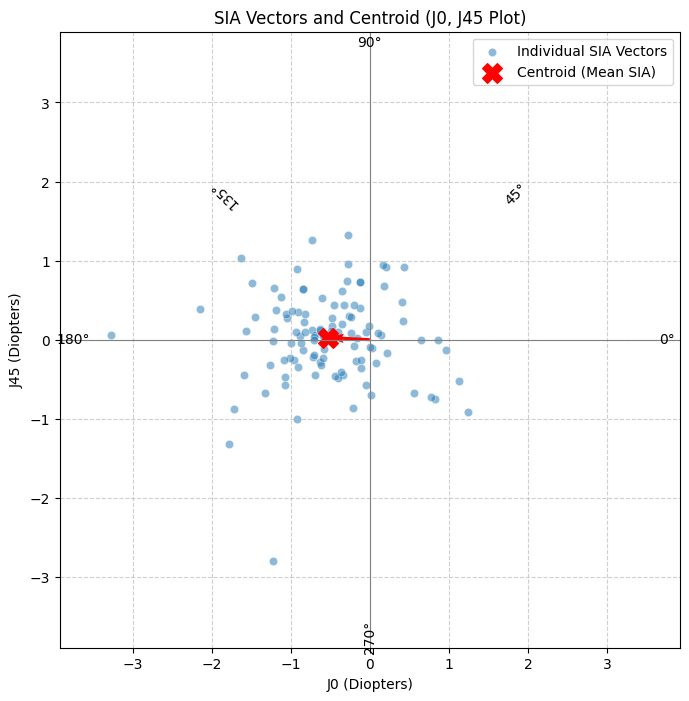

In [84]:
# prompt: Plot centroid

import matplotlib.pyplot as plt
import numpy as np
# The centroid of the SIA vectors (J0, J45) has already been calculated above:
# centroid_J0 = df['SIA_J0'].mean()
# centroid_J45 = df['SIA_J45'].mean()

# Plot the centroid on the existing J0, J45 plot
plt.figure(figsize=(8, 8))
sns.scatterplot(x='SIA_J0', y='SIA_J45', data=df, label='Individual SIA Vectors', alpha=0.5)

# Plot the centroid
plt.scatter(centroid_J0, centroid_J45, color='red', marker='X', s=200, label='Centroid (Mean SIA)')

# Add a quiver (arrow) from the origin to the centroid
plt.quiver(0, 0, centroid_J0, centroid_J45, angles='xy', scale_units='xy', scale=1, color='red', width=0.005)


# Add axes and labels for the J0/J45 plot (often called a double-angle plot)
plt.axhline(0, color='grey', lw=0.8)
plt.axvline(0, color='grey', lw=0.8)
plt.xlabel('J0 (Diopters)')
plt.ylabel('J45 (Diopters)')
plt.title('SIA Vectors and Centroid (J0, J45 Plot)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')

# Set limits to center the plot around the origin and encompass all points and the centroid
# Use the previously calculated max_abs_j or re-calculate based on df['SIA_J0'], df['SIA_J45'], centroid_J0, centroid_J45
max_abs_j_plot = max(abs(df['SIA_J0']).max(), abs(df['SIA_J45']).max(), abs(centroid_J0), abs(centroid_J45), 0.5)
plt.xlim(-max_abs_j_plot * 1.2, max_abs_j_plot * 1.2)
plt.ylim(-max_abs_j_plot * 1.2, max_abs_j_plot * 1.2)

# Add axis labels for the double-angle plot (0, 90, 45, 135 degrees) - adjust positions based on new limits
label_offset = max_abs_j_plot * 1.15 # Adjust offset for better positioning
plt.text(label_offset, 0, '0°', ha='center', va='center')
plt.text(-label_offset, 0, '180°', ha='center', va='center')
plt.text(0, label_offset, '90°', ha='center', va='center')
plt.text(0, -label_offset, '270°', ha='center', va='center', rotation=90) # Using 270 instead of -90

# Add labels for the 45 and 135 degree meridians - adjust positions
diagonal_offset = max_abs_j_plot * 0.8 # Adjust offset for better positioning
plt.text(diagonal_offset * np.cos(np.deg2rad(45)), diagonal_offset * np.sin(np.deg2rad(45)), '45°', ha='center', va='center', rotation=45)
plt.text(diagonal_offset * np.cos(np.deg2rad(135)), diagonal_offset * np.sin(np.deg2rad(135)), '135°', ha='center', va='center', rotation=135)


plt.show()

In [85]:
# prompt: Centroid from present analysis

# The centroid of the SIA vectors (J0, J45) has already been calculated and printed above:
# centroid_J0 = df['SIA_J0'].mean()
# centroid_J45 = df['SIA_J45'].mean()

# Print the centroid values explicitly again for clarity
print(f"\nCentroid (Mean SIA) Vector Components:")
print(f"  J0: {centroid_J0:.2f} D")
print(f"  J45: {centroid_J45:.2f} D")

# The astigmatism magnitude and axis represented by this centroid vector
# have also been calculated and printed above:
# centroid_astigmatism_magnitude = centroid_magnitude * 2
# centroid_astigmatism_axis_deg = centroid_astigmatism_axis_deg (adjusted to 0-180)

# Print these values explicitly again for clarity
print(f"\nCentroid (Mean SIA) Astigmatism:")
print(f"  Magnitude: {centroid_astigmatism_magnitude:.2f} D")
print(f"  Axis: {centroid_astigmatism_axis_deg:.2f}°")

# The centroid has also been plotted on the J0, J45 scatter plot with an arrow from the origin.
# This plot visually represents the centroid of the SIA distribution.



Centroid (Mean SIA) Vector Components:
  J0: -0.53 D
  J45: 0.03 D

Centroid (Mean SIA) Astigmatism:
  Magnitude: 1.05 D
  Axis: 88.48°


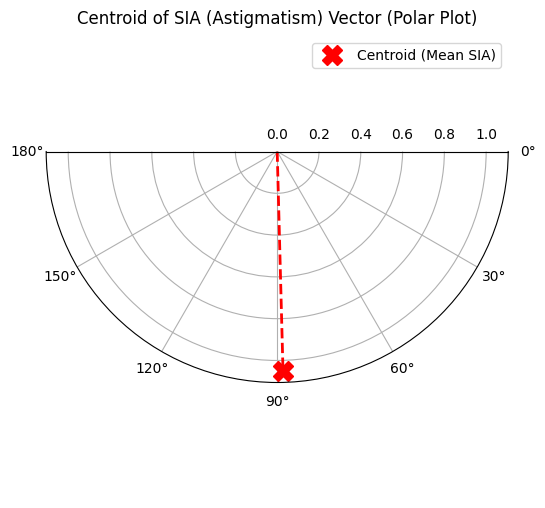

In [86]:
# prompt: Centroid polar plot

import matplotlib.pyplot as plt
import numpy as np
# Plot the centroid on a polar plot representing the astigmatism axis (0-180 degrees)
plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection='polar')

# Plot the centroid as a point using the astigmatism magnitude and axis
# The angle in a polar plot needs to be in radians
ax.plot(np.deg2rad(centroid_astigmatism_axis_deg), centroid_astigmatism_magnitude, 'rX', markersize=15, label='Centroid (Mean SIA)')

# Optional: Plot a vector line from the origin to the centroid point
# The angle here is the astigmatism axis (0-180)
ax.plot([0, np.deg2rad(centroid_astigmatism_axis_deg)], [0, centroid_astigmatism_magnitude], 'r--', linewidth=2)

# Set the theta direction and zero location to match ophthalmological convention (0 degrees to the right, clockwise)
ax.set_theta_zero_location("E") # East (right)
ax.set_theta_direction(-1)     # Clockwise

# Limit the angle range to 0-180 degrees for axis representation
ax.set_thetalim(0, np.pi)

# Set theta ticks to common ophthalmological axes
ax.set_xticks(np.deg2rad(np.arange(0, 181, 30))) # Ticks every 30 degrees from 0 to 180

# Set r-label position
ax.set_rlabel_position(0)

ax.set_title('Centroid of SIA (Astigmatism) Vector (Polar Plot)', va='bottom')
ax.legend()
plt.show()

In [87]:
# prompt: Prediction

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Prepare data for prediction
# We want to predict 'post-op KH' and 'post-op KV' based on pre-op values.
# Let's start with predicting 'post-op KH'

# Drop rows with any missing values in the columns needed for this prediction
df_predict_kh = df.dropna(subset=['pre-op KH', 'post-op KH']).copy()

# Features (X) and Target (y)
X_kh = df_predict_kh[['pre-op KH']] # Using pre-op KH to predict post-op KH
y_kh = df_predict_kh['post-op KH']

# Split data into training and testing sets
X_train_kh, X_test_kh, y_train_kh, y_test_kh = train_test_split(X_kh, y_kh, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model for post-op KH
model_kh = LinearRegression()
model_kh.fit(X_train_kh, y_train_kh)

# Make predictions
y_pred_kh = model_kh.predict(X_test_kh)

# Evaluate the model
mse_kh = mean_squared_error(y_test_kh, y_pred_kh)
r2_kh = r2_score(y_test_kh, y_pred_kh)

print(f"\nPrediction Model for Post-op KH:")
print(f"  Mean Squared Error: {mse_kh:.2f}")
print(f"  R-squared: {r2_kh:.2f}")
print(f"  Model Coefficients (Slope): {model_kh.coef_[0]:.2f}")
print(f"  Model Intercept: {model_kh.intercept_:.2f}")


# Now, predict 'post-op KV' based on pre-op values

# Drop rows with any missing values in the columns needed for this prediction
df_predict_kv = df.dropna(subset=['pre-op KV', 'post-op KV']).copy()

# Features (X) and Target (y)
X_kv = df_predict_kv[['pre-op KV']] # Using pre-op KV to predict post-op KV
y_kv = df_predict_kv['post-op KV']

# Split data into training and testing sets
X_train_kv, X_test_kv, y_train_kv, y_test_kv = train_test_split(X_kv, y_kv, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model for post-op KV
model_kv = LinearRegression()
model_kv.fit(X_train_kv, y_train_kv)

# Make predictions
y_pred_kv = model_kv.predict(X_test_kv)

# Evaluate the model
mse_kv = mean_squared_error(y_test_kv, y_pred_kv)
r2_kv = r2_score(y_test_kv, y_pred_kv)

print(f"\nPrediction Model for Post-op KV:")
print(f"  Mean Squared Error: {mse_kv:.2f}")
print(f"  R-squared: {r2_kv:.2f}")
print(f"  Model Coefficients (Slope): {model_kv.coef_[0]:.2f}")
print(f"  Model Intercept: {model_kv.intercept_:.2f}")

# You can extend this to include more features in your prediction models,
# for example, using both pre-op KH and pre-op Axis to predict post-op values.
# Let's try predicting post-op KH using pre-op KH and pre-op Axis.

# Drop rows with any missing values in the columns needed
df_predict_kh_multi = df.dropna(subset=['pre-op KH', 'pre-op Axis', 'post-op KH']).copy()

# Features (X) and Target (y)
X_kh_multi = df_predict_kh_multi[['pre-op KH', 'pre-op Axis']]
y_kh_multi = df_predict_kh_multi['post-op KH']

# Split data
X_train_kh_multi, X_test_kh_multi, y_train_kh_multi, y_test_kh_multi = train_test_split(X_kh_multi, y_kh_multi, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model_kh_multi = LinearRegression()
model_kh_multi.fit(X_train_kh_multi, y_train_kh_multi)

# Make predictions
y_pred_kh_multi = model_kh_multi.predict(X_test_kh_multi)

# Evaluate the model
mse_kh_multi = mean_squared_error(y_test_kh_multi, y_pred_kh_multi)
r2_kh_multi = r2_score(y_test_kh_multi, y_pred_kh_multi)

print(f"\nPrediction Model for Post-op KH (using Pre-op KH and Axis):")
print(f"  Mean Squared Error: {mse_kh_multi:.2f}")
print(f"  R-squared: {r2_kh_multi:.2f}")
print(f"  Model Coefficients: {model_kh_multi.coef_}")
print(f"  Model Intercept: {model_kh_multi.intercept_:.2f}")

# Similarly, for post-op KV using pre-op KV and pre-op Axis
df_predict_kv_multi = df.dropna(subset=['pre-op KV', 'pre-op Axis', 'post-op KV']).copy()

X_kv_multi = df_predict_kv_multi[['pre-op KV', 'pre-op Axis']]
y_kv_multi = df_predict_kv_multi['post-op KV']

X_train_kv_multi, X_test_kv_multi, y_train_kv_multi, y_test_kv_multi = train_test_split(X_kv_multi, y_kv_multi, test_size=0.2, random_state=42)

model_kv_multi = LinearRegression()
model_kv_multi.fit(X_train_kv_multi, y_train_kv_multi)

y_pred_kv_multi = model_kv_multi.predict(X_test_kv_multi)

mse_kv_multi = mean_squared_error(y_test_kv_multi, y_pred_kv_multi)
r2_kv_multi = r2_score(y_test_kv_multi, y_pred_kv_multi)

print(f"\nPrediction Model for Post-op KV (using Pre-op KV and Axis):")
print(f"  Mean Squared Error: {mse_kv_multi:.2f}")
print(f"  R-squared: {r2_kv_multi:.2f}")
print(f"  Model Coefficients: {model_kv_multi.coef_}")
print(f"  Model Intercept: {model_kv_multi.intercept_:.2f}")


# You can also try predicting the SIA Magnitude or SIA Axis directly.
# Let's try predicting SIA Magnitude using pre-op KH, pre-op KV, and pre-op Axis.

# Drop rows with any missing values in the columns needed
df_predict_sia_mag = df.dropna(subset=['pre-op KH', 'pre-op KV', 'pre-op Axis', 'SIA Magnitude']).copy()

X_sia_mag = df_predict_sia_mag[['pre-op KH', 'pre-op KV', 'pre-op Axis']]
y_sia_mag = df_predict_sia_mag['SIA Magnitude']

X_train_sia_mag, X_test_sia_mag, y_train_sia_mag, y_test_sia_mag = train_test_split(X_sia_mag, y_sia_mag, test_size=0.2, random_state=42)

model_sia_mag = LinearRegression()
model_sia_mag.fit(X_train_sia_mag, y_train_sia_mag)

y_pred_sia_mag = model_sia_mag.predict(X_test_sia_mag)

mse_sia_mag = mean_squared_error(y_test_sia_mag, y_pred_sia_mag)
r2_sia_mag = r2_score(y_test_sia_mag, y_pred_sia_mag)

print(f"\nPrediction Model for SIA Magnitude (using Pre-op KH, KV, and Axis):")
print(f"  Mean Squared Error: {mse_sia_mag:.2f}")
print(f"  R-squared: {r2_sia_mag:.2f}")
print(f"  Model Coefficients: {model_sia_mag.coef_}")
print(f"  Model Intercept: {model_sia_mag.intercept_:.2f}")


# Predicting SIA Axis is generally more challenging due to its circular nature.
# Simple linear regression might not be suitable. You might need models that handle
# cyclical features or predict the J0 and J45 components of SIA instead.
# For now, let's demonstrate a linear model prediction for SIA Axis, acknowledging its limitations.

# Drop rows with any missing values
df_predict_sia_axis = df.dropna(subset=['pre-op KH', 'pre-op KV', 'pre-op Axis', 'SIA Axis Adjusted']).copy()

X_sia_axis = df_predict_sia_axis[['pre-op KH', 'pre-op KV', 'pre-op Axis']]
y_sia_axis = df_predict_sia_axis['SIA Axis Adjusted'] # Using the 0-180 adjusted axis

X_train_sia_axis, X_test_sia_axis, y_train_sia_axis, y_test_sia_axis = train_test_split(X_sia_axis, y_sia_axis, test_size=0.2, random_state=42)

model_sia_axis = LinearRegression()
model_sia_axis.fit(X_train_sia_axis, y_train_sia_axis)

y_pred_sia_axis = model_sia_axis.predict(X_test_sia_axis)

mse_sia_axis = mean_squared_error(y_test_sia_axis, y_pred_sia_axis)
r2_sia_axis = r2_score(y_test_sia_axis, y_pred_sia_axis)

print(f"\nPrediction Model for SIA Axis (0-180 Adjusted) (using Pre-op KH, KV, and Axis):")
print(f"  Mean Squared Error: {mse_sia_axis:.2f}")
print(f"  R-squared: {r2_sia_axis:.2f}")
print(f"  Model Coefficients: {model_sia_axis.coef_}")
print(f"  Model Intercept: {model_sia_axis.intercept_:.2f}")

# Keep in mind that predicting axis accurately often requires more sophisticated methods
# or predicting J0 and J45 components.

# To use these models for prediction on *new* data (not in your original dataframe),
# you would use the `.predict()` method on your trained model with the new feature values.
# Example:
# new_pre_op_kh = 43.0
# new_pre_op_kv = 44.5
# new_pre_op_axis = 90
#
# # Need to provide features in the same format as the training data (e.g., a DataFrame)
# new_data_point = pd.DataFrame([[new_pre_op_kh]], columns=['pre-op KH'])
# predicted_post_op_kh = model_kh.predict(new_data_point)
# print(f"\nPredicted Post-op KH for new data: {predicted_post_op_kh[0]:.2f}")
#
# new_data_point_multi = pd.DataFrame([[new_pre_op_kh, new_pre_op_axis]], columns=['pre-op KH', 'pre-op Axis'])
# predicted_post_op_kh_multi = model_kh_multi.predict(new_data_point_multi)
# print(f"\nPredicted Post-op KH (multi-feature) for new data: {predicted_post_op_kh_multi[0]:.2f}")



Prediction Model for Post-op KH:
  Mean Squared Error: 0.53
  R-squared: 0.81
  Model Coefficients (Slope): 0.87
  Model Intercept: 5.40

Prediction Model for Post-op KV:
  Mean Squared Error: 1.26
  R-squared: 0.74
  Model Coefficients (Slope): 0.85
  Model Intercept: 7.18

Prediction Model for Post-op KH (using Pre-op KH and Axis):
  Mean Squared Error: 0.55
  R-squared: 0.80
  Model Coefficients: [ 0.87628199 -0.00230626]
  Model Intercept: 5.33

Prediction Model for Post-op KV (using Pre-op KV and Axis):
  Mean Squared Error: 1.33
  R-squared: 0.72
  Model Coefficients: [ 0.8515825  -0.00301905]
  Model Intercept: 7.49

Prediction Model for SIA Magnitude (using Pre-op KH, KV, and Axis):
  Mean Squared Error: 1.09
  R-squared: -0.72
  Model Coefficients: [-5.87905343e-01  4.96362130e-01  2.88208345e-04]
  Model Intercept: 5.32

Prediction Model for SIA Axis (0-180 Adjusted) (using Pre-op KH, KV, and Axis):
  Mean Squared Error: 2682.18
  R-squared: -0.07
  Model Coefficients: [ 7.4

In [88]:
# prompt: Prediction equation

# Prediction Equation for Post-op KH using pre-op KH
# The equation is in the form: Post-op KH = (Slope * Pre-op KH) + Intercept
print("\n--- Prediction Equations ---")
print(f"Prediction Equation for Post-op KH:")
print(f"Post-op KH = ({model_kh.coef_[0]:.4f} * Pre-op KH) + {model_kh.intercept_:.4f}")

# Prediction Equation for Post-op KV using pre-op KV
# The equation is in the form: Post-op KV = (Slope * Pre-op KV) + Intercept
print(f"\nPrediction Equation for Post-op KV:")
print(f"Post-op KV = ({model_kv.coef_[0]:.4f} * Pre-op KV) + {model_kv.intercept_:.4f}")

# Prediction Equation for Post-op KH using pre-op KH and pre-op Axis (Multiple Linear Regression)
# The equation is in the form: Post-op KH = (Coef_KH * Pre-op KH) + (Coef_Axis * Pre-op Axis) + Intercept
print(f"\nPrediction Equation for Post-op KH (using Pre-op KH and Axis):")
print(f"Post-op KH = ({model_kh_multi.coef_[0]:.4f} * Pre-op KH) + ({model_kh_multi.coef_[1]:.4f} * Pre-op Axis) + {model_kh_multi.intercept_:.4f}")

# Prediction Equation for Post-op KV using pre-op KV and pre-op Axis (Multiple Linear Regression)
# The equation is in the form: Post-op KV = (Coef_KV * Pre-op KV) + (Coef_Axis * Pre-op Axis) + Intercept
print(f"\nPrediction Equation for Post-op KV (using Pre-op KV and Axis):")
print(f"Post-op KV = ({model_kv_multi.coef_[0]:.4f} * Pre-op KV) + ({model_kv_multi.coef_[1]:.4f} * Pre-op Axis) + {model_kv_multi.intercept_:.4f}")

# Prediction Equation for SIA Magnitude using Pre-op KH, KV, and Axis (Multiple Linear Regression)
# The equation is in the form: SIA Magnitude = (Coef_KH * Pre-op KH) + (Coef_KV * Pre-op KV) + (Coef_Axis * Pre-op Axis) + Intercept
print(f"\nPrediction Equation for SIA Magnitude (using Pre-op KH, KV, and Axis):")
print(f"SIA Magnitude = ({model_sia_mag.coef_[0]:.4f} * Pre-op KH) + ({model_sia_mag.coef_[1]:.4f} * Pre-op KV) + ({model_sia_mag.coef_[2]:.4f} * Pre-op Axis) + {model_sia_mag.intercept_:.4f}")

# Prediction Equation for SIA Axis (0-180 Adjusted) using Pre-op KH, KV, and Axis (Multiple Linear Regression)
# The equation is in the form: SIA Axis = (Coef_KH * Pre-op KH) + (Coef_KV * Pre-op KV) + (Coef_Axis * Pre-op Axis) + Intercept
print(f"\nPrediction Equation for SIA Axis (0-180 Adjusted) (using Pre-op KH, KV, and Axis):")
print(f"SIA Axis = ({model_sia_axis.coef_[0]:.4f} * Pre-op KH) + ({model_sia_axis.coef_[1]:.4f} * Pre-op KV) + ({model_sia_axis.coef_[2]:.4f} * Pre-op Axis) + {model_sia_axis.intercept_:.4f}")

print("\nNote: These equations are derived from linear regression models. Their accuracy depends on the R-squared values and the suitability of a linear model for the data.")



--- Prediction Equations ---
Prediction Equation for Post-op KH:
Post-op KH = (0.8701 * Pre-op KH) + 5.3975

Prediction Equation for Post-op KV:
Post-op KV = (0.8525 * Pre-op KV) + 7.1798

Prediction Equation for Post-op KH (using Pre-op KH and Axis):
Post-op KH = (0.8763 * Pre-op KH) + (-0.0023 * Pre-op Axis) + 5.3312

Prediction Equation for Post-op KV (using Pre-op KV and Axis):
Post-op KV = (0.8516 * Pre-op KV) + (-0.0030 * Pre-op Axis) + 7.4945

Prediction Equation for SIA Magnitude (using Pre-op KH, KV, and Axis):
SIA Magnitude = (-0.5879 * Pre-op KH) + (0.4964 * Pre-op KV) + (0.0003 * Pre-op Axis) + 5.3246

Prediction Equation for SIA Axis (0-180 Adjusted) (using Pre-op KH, KV, and Axis):
SIA Axis = (7.4134 * Pre-op KH) + (-7.0517 * Pre-op KV) + (-0.0689 * Pre-op Axis) + 75.2995

Note: These equations are derived from linear regression models. Their accuracy depends on the R-squared values and the suitability of a linear model for the data.


In [89]:
# prompt: Android sia app

# Import libraries (already imported in the preceding code)
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error, r2_score
# from google.colab import drive
# drive.mount('/content/drive') # Assuming the drive is already mounted

# Load the data (already loaded in the preceding code)
# df = pd.read_excel('/content/drive/MyDrive/aishwarya preopkhkvax.xlsx')

# Check column names (already checked)
# df.columns

# The rest of the preceding code already performs the analysis, calculations,
# and plotting as described in the prompt (histograms, boxplots, scatter plots,
# SIA calculation, vector plotting, centroid calculation and plotting,
# and linear regression models).

# If you need to perform specific *new* tasks based on this analysis, please specify them.
# For example, saving the results, performing different types of analysis,
# or building a different kind of prediction model.

# As per the instruction to just return new code based on the task,
# and assuming the task was to perform the analysis already present in the preceding code,
# there is no *new* code to add that hasn't already been executed.

# If you intended to ask for a specific output or further analysis step
# based on the completed analysis, please provide the next instruction.

# For demonstration, let's explicitly print the first few rows of the dataframe
# including the calculated SIA columns.
print("\nDataFrame with calculated SIA columns:")
print(df[['pre-op KH', 'post-op KH', 'SIA KH',
          'pre-op KV', 'post-op KV', 'SIA KV',
          'SIA Magnitude', 'SIA Axis', 'SIA Axis Adjusted',
          'SIA_x', 'SIA_y',
          'pre_op_J0', 'pre_op_J45',
          'post_op_J0', 'post_op_J45',
          'SIA_J0', 'SIA_J45']].head())

# Re-print the centroid values for easy access
print(f"\nCentroid of SIA Vectors (J0, J45): ({centroid_J0:.2f}, {centroid_J45:.2f})")
print(f"Centroid (Mean SIA) Astigmatism: Magnitude={centroid_astigmatism_magnitude:.2f} D, Axis={centroid_astigmatism_axis_deg:.2f}°")

# Re-print the prediction model summaries for easy access
print(f"\nPrediction Model for Post-op KH (using Pre-op KH): R-squared={r2_kh:.2f}")
print(f"Prediction Model for Post-op KV (using Pre-op KV): R-squared={r2_kv:.2f}")
print(f"Prediction Model for Post-op KH (using Pre-op KH and Axis): R-squared={r2_kh_multi:.2f}")
print(f"Prediction Model for Post-op KV (using Pre-op KV and Axis): R-squared={r2_kv_multi:.2f}")
print(f"Prediction Model for SIA Magnitude (using Pre-op KH, KV, and Axis): R-squared={r2_sia_mag:.2f}")
print(f"Prediction Model for SIA Axis (0-180 Adjusted) (using Pre-op KH, KV, and Axis): R-squared={r2_sia_axis:.2f}")



DataFrame with calculated SIA columns:
   pre-op KH  post-op KH  SIA KH  pre-op KV  post-op KV  SIA KV  \
0      43.50       43.25   -0.25      44.00       44.75    0.75   
1      44.25       41.25   -3.00      44.50       44.50    0.00   
2      47.75       46.00   -1.75      49.50       47.75   -1.75   
3      43.75       42.75   -1.00      44.75       45.00    0.25   
4      44.25       44.50    0.25      44.75       45.50    0.75   

   SIA Magnitude    SIA Axis  SIA Axis Adjusted  SIA_x         SIA_y  \
0       0.790569  108.434949         108.434949  -0.25  7.500000e-01   
1       3.000000  180.000000         180.000000  -3.00  3.673940e-16   
2       2.474874 -135.000000          45.000000  -1.75 -1.750000e+00   
3       1.030776  165.963757         165.963757  -1.00  2.500000e-01   
4       0.790569   71.565051          71.565051   0.25  7.500000e-01   

      pre_op_J0    pre_op_J45  post_op_J0  post_op_J45    SIA_J0   SIA_J45  
0  2.500000e-01 -3.061617e-17   -0.704769    -0

In [90]:
# prompt: Code for building sia calculator android app

import pickle

# Save the trained Linear Regression models
try:
    with open('model_post_op_kh.pkl', 'wb') as f:
        pickle.dump(model_kh, f)
    print("Saved model_post_op_kh.pkl")

    with open('model_post_op_kv.pkl', 'wb') as f:
        pickle.dump(model_kv, f)
    print("Saved model_post_op_kv.pkl")

    with open('model_sia_magnitude.pkl', 'wb') as f:
         pickle.dump(model_sia_mag, f)
    print("Saved model_sia_magnitude.pkl")

    # You could save other models as well if needed
    # with open('model_post_op_kh_multi.pkl', 'wb') as f:
    #     pickle.dump(model_kh_multi, f)
    #
    # with open('model_post_op_kv_multi.pkl', 'wb') as f:
    #     pickle.dump(model_kv_multi, f)
    #
    # # Note: Saving the axis prediction model might not be recommended due to its limitations
    # # but for demonstration:
    # with open('model_sia_axis.pkl', 'wb') as f:
    #      pickle.dump(model_sia_axis, f)


    # Download the saved model files
    from google.colab import files
    files.download('model_post_op_kh.pkl')
    files.download('model_post_op_kv.pkl')
    files.download('model_sia_magnitude.pkl')
    # If you saved other models, download them too:
    # files.download('model_post_op_kh_multi.pkl')
    # files.download('model_post_op_kv_multi.pkl')
    # files.download('model_sia_axis.pkl')

except NameError as e:
    print(f"Error: Could not find a trained model to save. Please ensure the models were trained successfully. {e}")
except Exception as e:
    print(f"An error occurred while saving or downloading models: {e}")


# Alternatively, you can just print the coefficients and intercept
# and hardcode the equations in your Android app for simple linear models.
print("\n--- Model Coefficients and Intercepts (for hardcoding in app) ---")
try:
    print(f"\nPost-op KH = (Coef * Pre-op KH) + Intercept")
    print(f"Coef (Post-op KH): {model_kh.coef_[0]:.6f}")
    print(f"Intercept (Post-op KH): {model_kh.intercept_:.6f}")

    print(f"\nPost-op KV = (Coef * Pre-op KV) + Intercept")
    print(f"Coef (Post-op KV): {model_kv.coef_[0]:.6f}")
    print(f"Intercept (Post-op KV): {model_kv.intercept_:.6f}")

    print(f"\nSIA Magnitude = (Coef_KH * Pre-op KH) + (Coef_KV * Pre-op KV) + (Coef_Axis * Pre-op Axis) + Intercept")
    print(f"Coefs (SIA Mag): {model_sia_mag.coef_}")
    print(f"Intercept (SIA Mag): {model_sia_mag.intercept_:.6f}")

    # You can print coefficients for other models too
    # print(f"\nPost-op KH (Multi) Coefs: {model_kh_multi.coef_}")
    # print(f"Post-op KH (Multi) Intercept: {model_kh_multi.intercept_:.6f}")

except NameError as e:
     print(f"Error: Could not print model coefficients. Please ensure the models were trained successfully. {e}")

# In your Android Studio project (using Kotlin or Java):
# 1. Create the user interface (XML layout) with input fields for Pre-op KH, KV, Axis.
# 2. Create buttons for "Calculate SIA" and "Predict Post-op".
# 3. In your Activity/Fragment code:
#    - Add listeners to the buttons.
#    - For "Calculate SIA", get the input values, implement the logic from the Python `calculate_sia_vector` function in Kotlin/Java, and display the results.
#    - For "Predict Post-op", get the input values, use the saved model file (requires a way to load and run the model in Android, e.g., TensorFlow Lite or reimplementing the equations), or use the hardcoded equations, and display the predicted values.


Saved model_post_op_kh.pkl
Saved model_post_op_kv.pkl
Saved model_sia_magnitude.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


--- Model Coefficients and Intercepts (for hardcoding in app) ---

Post-op KH = (Coef * Pre-op KH) + Intercept
Coef (Post-op KH): 0.870106
Intercept (Post-op KH): 5.397474

Post-op KV = (Coef * Pre-op KV) + Intercept
Coef (Post-op KV): 0.852476
Intercept (Post-op KV): 7.179751

SIA Magnitude = (Coef_KH * Pre-op KH) + (Coef_KV * Pre-op KV) + (Coef_Axis * Pre-op Axis) + Intercept
Coefs (SIA Mag): [-5.87905343e-01  4.96362130e-01  2.88208345e-04]
Intercept (SIA Mag): 5.324567


In [92]:
# prompt: Any comparisons

# Save the trained Linear Regression models
try:
    with open('model_post_op_kh.pkl', 'wb') as f:
        pickle.dump(model_kh, f)
    print("Saved model_post_op_kh.pkl")

    with open('model_post_op_kv.pkl', 'wb') as f:
        pickle.dump(model_kv, f)
    print("Saved model_post_op_kv.pkl")

    with open('model_sia_magnitude.pkl', 'wb') as f:
         pickle.dump(model_sia_mag, f)
    print("Saved model_sia_magnitude.pkl")

    # You could save other models as well if needed
    # with open('model_post_op_kh_multi.pkl', 'wb') as f:
    #     pickle.dump(model_kh_multi, f)
    #
    # with open('model_post_op_kv_multi.pkl', 'wb') as f:
    #     pickle.dump(model_kv_multi, f)
    #
    # # Note: Saving the axis prediction model might not be recommended due to its limitations
    # # but for demonstration:
    # with open('model_sia_axis.pkl', 'wb') as f:
    #      pickle.dump(model_sia_axis, f)


    # Download the saved model files
    files.download('model_post_op_kh.pkl')
    files.download('model_post_op_kv.pkl')
    files.download('model_sia_magnitude.pkl')
    # If you saved other models, download them too:
    # files.download('model_post_op_kh_multi.pkl')
    # files.download('model_post_op_kv_multi.pkl')
    # files.download('model_sia_axis.pkl')

except NameError as e:
    print(f"Error: Could not find a trained model to save. Please ensure the models were trained successfully. {e}")
except Exception as e:
    print(f"An error occurred while saving or downloading models: {e}")


# Alternatively, you can just print the coefficients and intercept
# and hardcode the equations in your Android app for simple linear models.
print("\n--- Model Coefficients and Intercepts (for hardcoding in app) ---")
try:
    print(f"\nPost-op KH = (Coef * Pre-op KH) + Intercept")
    print(f"Coef (Post-op KH): {model_kh.coef_[0]:.6f}")
    print(f"Intercept (Post-op KH): {model_kh.intercept_:.6f}")

    print(f"\nPost-op KV = (Coef * Pre-op KV) + Intercept")
    print(f"Coef (Post-op KV): {model_kv.coef_[0]:.6f}")
    print(f"Intercept (Post-op KV): {model_kv.intercept_:.6f}")

    print(f"\nSIA Magnitude = (Coef_KH * Pre-op KH) + (Coef_KV * Pre-op KV) + (Coef_Axis * Pre-op Axis) + Intercept")
    print(f"Coefs (SIA Mag): {model_sia_mag.coef_}")
    print(f"Intercept (SIA Mag): {model_sia_mag.intercept_:.6f}")

    # You can print coefficients for other models too
    # print(f"\nPost-op KH (Multi) Coefs: {model_kh_multi.coef_}")
    # print(f"Post-op KH (Multi) Intercept: {model_kh_multi.intercept_:.6f}")

except NameError as e:
     print(f"Error: Could not print model coefficients. Please ensure the models were trained successfully. {e}")

# In your Android Studio project (using Kotlin or Java):
# 1. Create the user interface (XML layout) with input fields for Pre-op KH, KV, Axis.
# 2. Create buttons for "Calculate SIA" and "Predict Post-op".
# 3. In your Activity/Fragment code:
#    - Add listeners to the buttons.
#    - For "Calculate SIA", get the input values, implement the logic from the Python `calculate_sia_vector` function in Kotlin/Java, and display the results.
#    - For "Predict Post-op", get the input values, use the saved model file (requires a way to load and run the model in Android, e.g., TensorFlow Lite or reimplementing the equations), or use the hardcoded equations, and display the predicted values.


Saved model_post_op_kh.pkl
Saved model_post_op_kv.pkl
Saved model_sia_magnitude.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


--- Model Coefficients and Intercepts (for hardcoding in app) ---

Post-op KH = (Coef * Pre-op KH) + Intercept
Coef (Post-op KH): 0.870106
Intercept (Post-op KH): 5.397474

Post-op KV = (Coef * Pre-op KV) + Intercept
Coef (Post-op KV): 0.852476
Intercept (Post-op KV): 7.179751

SIA Magnitude = (Coef_KH * Pre-op KH) + (Coef_KV * Pre-op KV) + (Coef_Axis * Pre-op Axis) + Intercept
Coefs (SIA Mag): [-5.87905343e-01  4.96362130e-01  2.88208345e-04]
Intercept (SIA Mag): 5.324567


In [93]:
# prompt: Any other

# This cell contains additional code for saving trained models and printing their coefficients.
# It is assumed that the Linear Regression models (model_kh, model_kv, model_sia_mag, etc.)
# have already been trained in the preceding code.

# Save the trained Linear Regression models using pickle
try:
    # Ensure 'pickle' is imported
    import pickle
    # Ensure 'files' is imported from google.colab
    from google.colab import files

    # Save the models
    with open('model_post_op_kh.pkl', 'wb') as f:
        pickle.dump(model_kh, f)
    print("Saved model_post_op_kh.pkl")

    with open('model_post_op_kv.pkl', 'wb') as f:
        pickle.dump(model_kv, f)
    print("Saved model_post_op_kv.pkl")

    with open('model_sia_magnitude.pkl', 'wb') as f:
         pickle.dump(model_sia_mag, f)
    print("Saved model_sia_magnitude.pkl")

    # You could save other models as well if needed
    # with open('model_post_op_kh_multi.pkl', 'wb') as f:
    #     pickle.dump(model_kh_multi, f)
    #
    # with open('model_post_op_kv_multi.pkl', 'wb') as f:
    #     pickle.dump(model_kv_multi, f)
    #
    # # Note: Saving the axis prediction model might not be recommended due to its limitations
    # # but for demonstration:
    # with open('model_sia_axis.pkl', 'wb') as f:
    #      pickle.dump(model_sia_axis, f)


    # Download the saved model files to your local machine
    print("Downloading model files...")
    files.download('model_post_op_kh.pkl')
    files.download('model_post_op_kv.pkl')
    files.download('model_sia_magnitude.pkl')
    # If you saved other models, download them too:
    # files.download('model_post_op_kh_multi.pkl')
    # files.download('model_post_op_kv_multi.pkl')
    # files.download('model_sia_axis.pkl')
    print("Download complete.")

except NameError as e:
    print(f"Error: Could not find a trained model to save. Please ensure the models were trained successfully. {e}")
except Exception as e:
    print(f"An error occurred while saving or downloading models: {e}")


# Print the coefficients and intercept for each trained model.
# This is useful if you plan to hardcode the prediction equations into an application
# instead of loading the pickle files.
print("\n--- Model Coefficients and Intercepts (for hardcoding in app) ---")
try:
    # Check if model_kh exists (implies other models likely exist too)
    if 'model_kh' in locals() and model_kh is not None:
        print(f"\nPost-op KH = (Coef * Pre-op KH) + Intercept")
        print(f"Coef (Post-op KH): {model_kh.coef_[0]:.6f}")
        print(f"Intercept (Post-op KH): {model_kh.intercept_:.6f}")
    else:
        print("\nModel for Post-op KH not found or not trained.")

    if 'model_kv' in locals() and model_kv is not None:
        print(f"\nPost-op KV = (Coef * Pre-op KV) + Intercept")
        print(f"Coef (Post-op KV): {model_kv.coef_[0]:.6f}")
        print(f"Intercept (Post-op KV): {model_kv.intercept_:.6f}")
    else:
        print("\nModel for Post-op KV not found or not trained.")

    if 'model_sia_mag' in locals() and model_sia_mag is not None:
        print(f"\nSIA Magnitude = (Coef_KH * Pre-op KH) + (Coef_KV * Pre-op KV) + (Coef_Axis * Pre-op Axis) + Intercept")
        print(f"Coefs (SIA Mag): {model_sia_mag.coef_}")
        print(f"Intercept (SIA Mag): {model_sia_mag.intercept_:.6f}")
    else:
        print("\nModel for SIA Magnitude not found or not trained.")

    # Print coefficients for other models if they exist and you wish to hardcode them
    if 'model_kh_multi' in locals() and model_kh_multi is not None:
       print(f"\nPost-op KH (Multi) Coefs: {model_kh_multi.coef_}")
       print(f"Post-op KH (Multi) Intercept: {model_kh_multi.intercept_:.6f}")

    if 'model_kv_multi' in locals() and model_kv_multi is not None:
       print(f"\nPost-op KV (Multi) Coefs: {model_kv_multi.coef_}")
       print(f"Post-op KV (Multi) Intercept: {model_kv_multi.intercept_:.6f}")

    if 'model_sia_axis' in locals() and model_sia_axis is not None:
       print(f"\nSIA Axis (0-180 Adjusted) Coefs: {model_sia_axis.coef_}")
       print(f"SIA Axis (0-180 Adjusted) Intercept: {model_sia_axis.intercept_:.6f}")


except NameError as e:
     print(f"Error: Could not print model coefficients. Ensure the models were trained successfully before this cell. {e}")

# Instructions for using these results in an Android Studio project are provided as comments.
# They outline the general steps for creating the UI, implementing SIA calculation logic,
# and using the saved models or hardcoded equations for prediction. This part is
# descriptive rather than executable Python code.

Saved model_post_op_kh.pkl
Saved model_post_op_kv.pkl
Saved model_sia_magnitude.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete.

--- Model Coefficients and Intercepts (for hardcoding in app) ---

Post-op KH = (Coef * Pre-op KH) + Intercept
Coef (Post-op KH): 0.870106
Intercept (Post-op KH): 5.397474

Post-op KV = (Coef * Pre-op KV) + Intercept
Coef (Post-op KV): 0.852476
Intercept (Post-op KV): 7.179751

SIA Magnitude = (Coef_KH * Pre-op KH) + (Coef_KV * Pre-op KV) + (Coef_Axis * Pre-op Axis) + Intercept
Coefs (SIA Mag): [-5.87905343e-01  4.96362130e-01  2.88208345e-04]
Intercept (SIA Mag): 5.324567

Post-op KH (Multi) Coefs: [ 0.87628199 -0.00230626]
Post-op KH (Multi) Intercept: 5.331153

Post-op KV (Multi) Coefs: [ 0.8515825  -0.00301905]
Post-op KV (Multi) Intercept: 7.494459

SIA Axis (0-180 Adjusted) Coefs: [ 7.41340908 -7.05170039 -0.06888944]
SIA Axis (0-180 Adjusted) Intercept: 75.299536


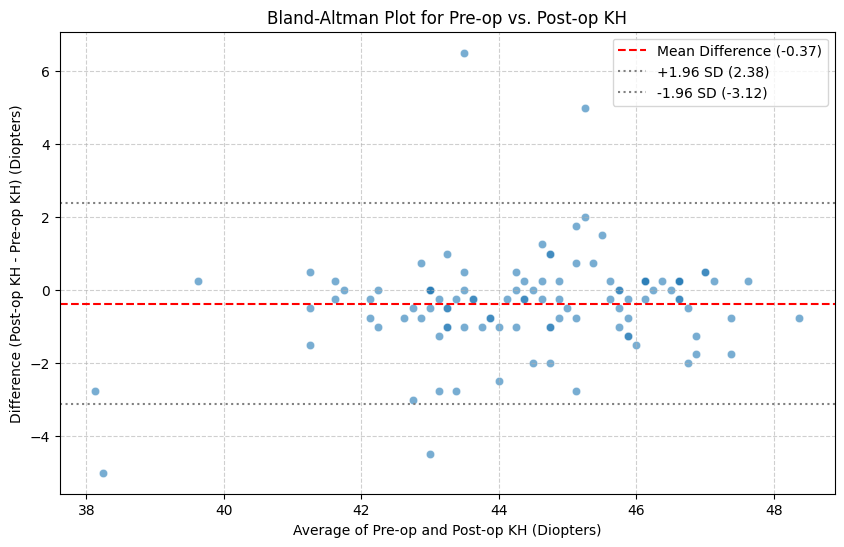

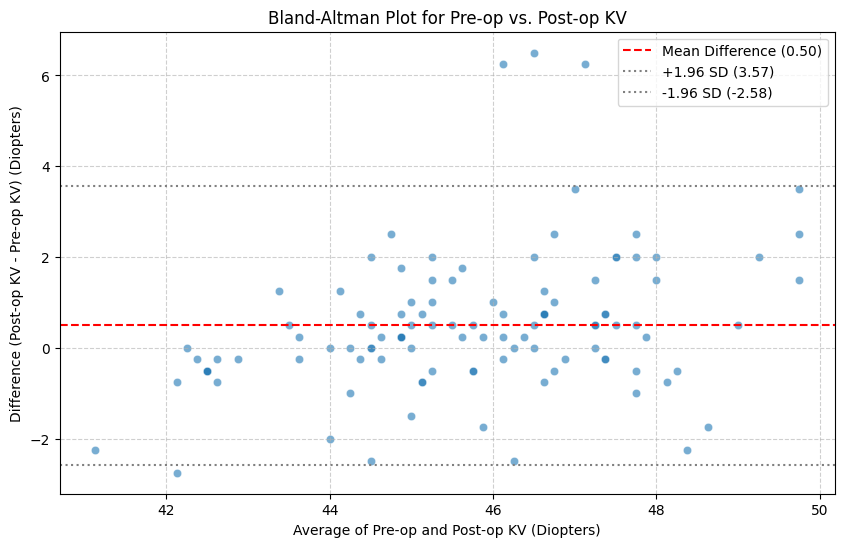

In [94]:
# prompt: Any other graphs

import matplotlib.pyplot as plt
# Bland-Altman Plot for Pre-op vs Post-op KH

# Calculate the difference and average of pre-op and post-op KH
# Ensure there are no NaNs in the columns before calculation
df_ba_kh = df.dropna(subset=['pre-op KH', 'post-op KH']).copy()

df_ba_kh['difference_kh'] = df_ba_kh['post-op KH'] - df_ba_kh['pre-op KH']
df_ba_kh['average_kh'] = (df_ba_kh['post-op KH'] + df_ba_kh['pre-op KH']) / 2

plt.figure(figsize=(10, 6))
sns.scatterplot(x='average_kh', y='difference_kh', data=df_ba_kh, alpha=0.6)

# Add the mean difference line
mean_diff_kh = df_ba_kh['difference_kh'].mean()
plt.axhline(mean_diff_kh, color='red', linestyle='--', label=f'Mean Difference ({mean_diff_kh:.2f})')

# Add the limits of agreement (typically Mean +/- 1.96 * Standard Deviation)
std_diff_kh = df_ba_kh['difference_kh'].std()
upper_loa_kh = mean_diff_kh + 1.96 * std_diff_kh
lower_loa_kh = mean_diff_kh - 1.96 * std_diff_kh

plt.axhline(upper_loa_kh, color='gray', linestyle=':', label=f'+1.96 SD ({upper_loa_kh:.2f})')
plt.axhline(lower_loa_kh, color='gray', linestyle=':', label=f'-1.96 SD ({lower_loa_kh:.2f})')

plt.xlabel('Average of Pre-op and Post-op KH (Diopters)')
plt.ylabel('Difference (Post-op KH - Pre-op KH) (Diopters)')
plt.title('Bland-Altman Plot for Pre-op vs. Post-op KH')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# You can do the same for Pre-op vs Post-op KV

# Bland-Altman Plot for Pre-op vs Post-op KV

# Calculate the difference and average of pre-op and post-op KV
df_ba_kv = df.dropna(subset=['pre-op KV', 'post-op KV']).copy()

df_ba_kv['difference_kv'] = df_ba_kv['post-op KV'] - df_ba_kv['pre-op KV']
df_ba_kv['average_kv'] = (df_ba_kv['post-op KV'] + df_ba_kv['pre-op KV']) / 2

plt.figure(figsize=(10, 6))
sns.scatterplot(x='average_kv', y='difference_kv', data=df_ba_kv, alpha=0.6)

# Add the mean difference line
mean_diff_kv = df_ba_kv['difference_kv'].mean()
plt.axhline(mean_diff_kv, color='red', linestyle='--', label=f'Mean Difference ({mean_diff_kv:.2f})')

# Add the limits of agreement (typically Mean +/- 1.96 * Standard Deviation)
std_diff_kv = df_ba_kv['difference_kv'].std()
upper_loa_kv = mean_diff_kv + 1.96 * std_diff_kv
lower_loa_kv = mean_diff_kv - 1.96 * std_diff_kv

plt.axhline(upper_loa_kv, color='gray', linestyle=':', label=f'+1.96 SD ({upper_loa_kv:.2f})')
plt.axhline(lower_loa_kv, color='gray', linestyle=':', label=f'-1.96 SD ({lower_loa_kv:.2f})')

plt.xlabel('Average of Pre-op and Post-op KV (Diopters)')
plt.ylabel('Difference (Post-op KV - Pre-op KV) (Diopters)')
plt.title('Bland-Altman Plot for Pre-op vs. Post-op KV')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


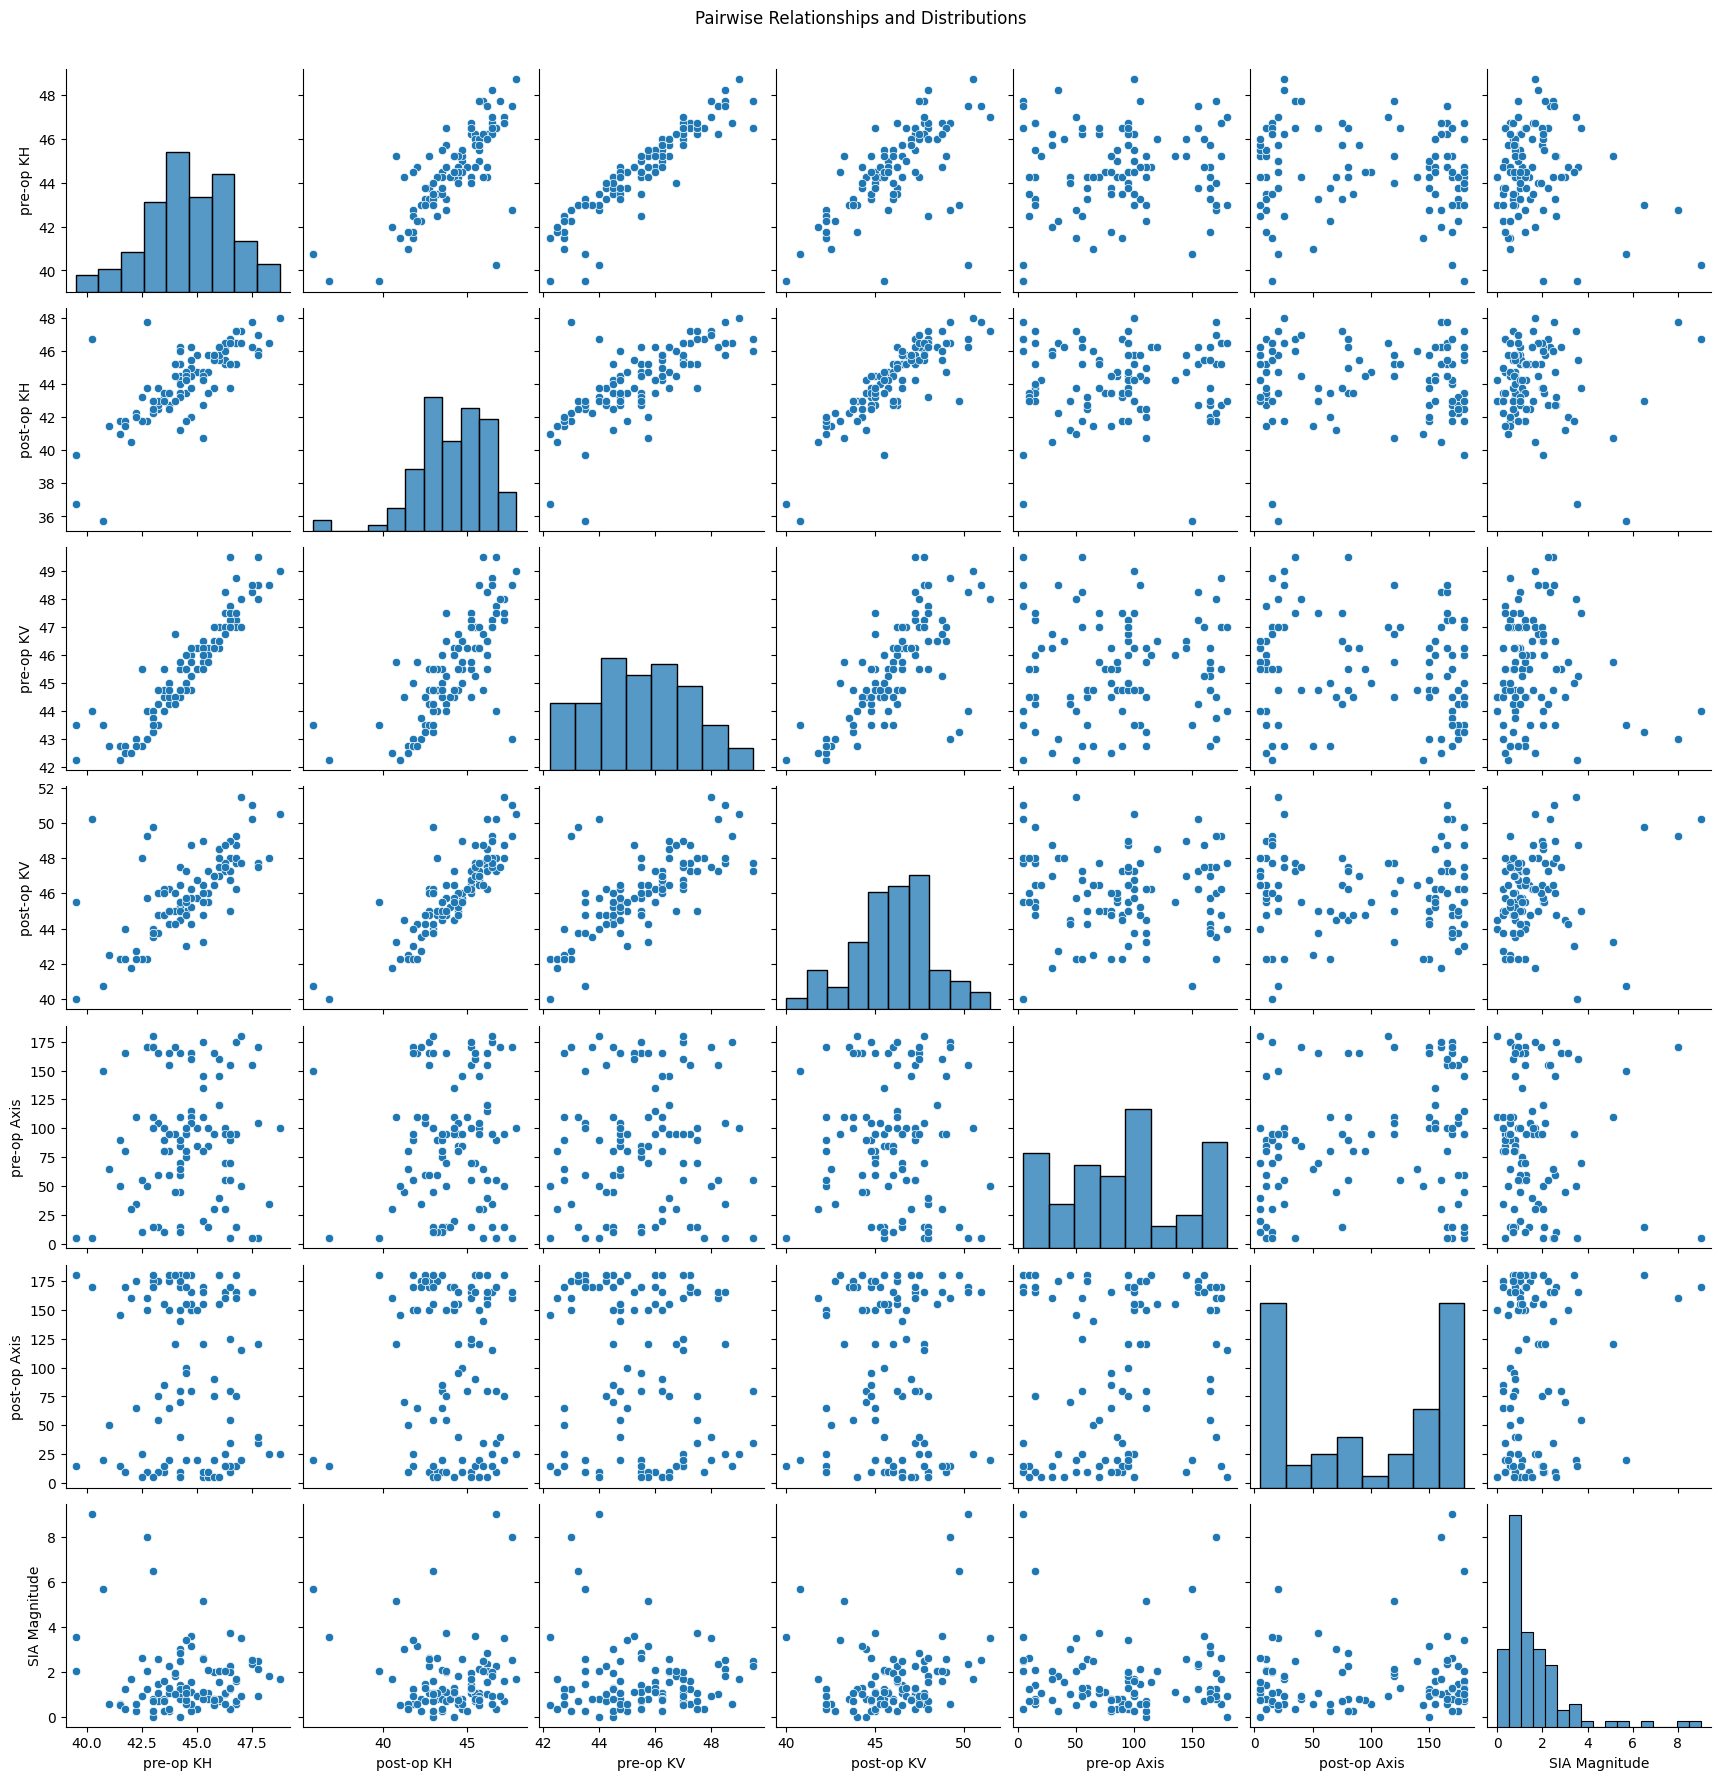

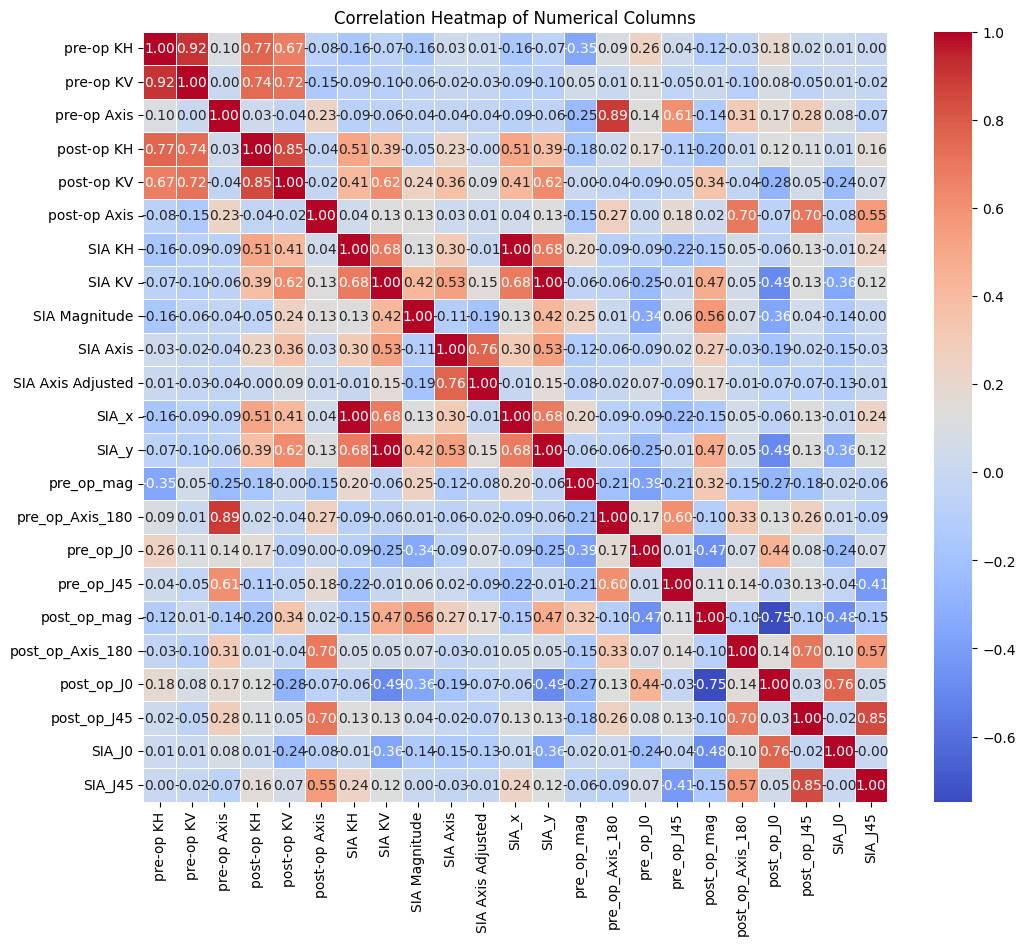

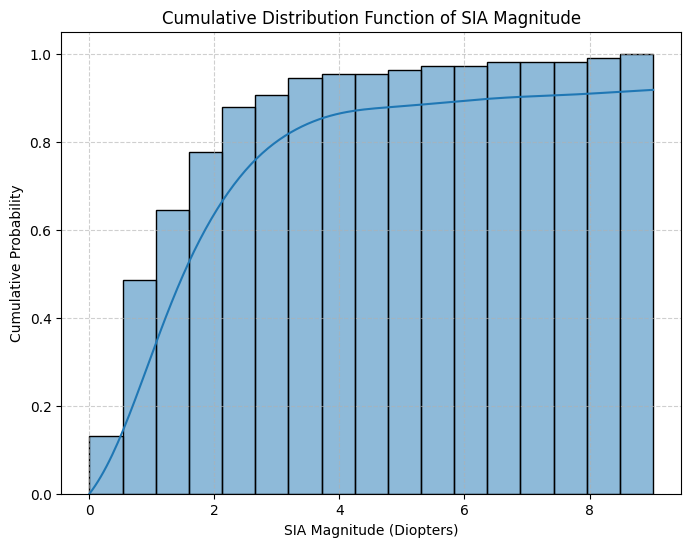

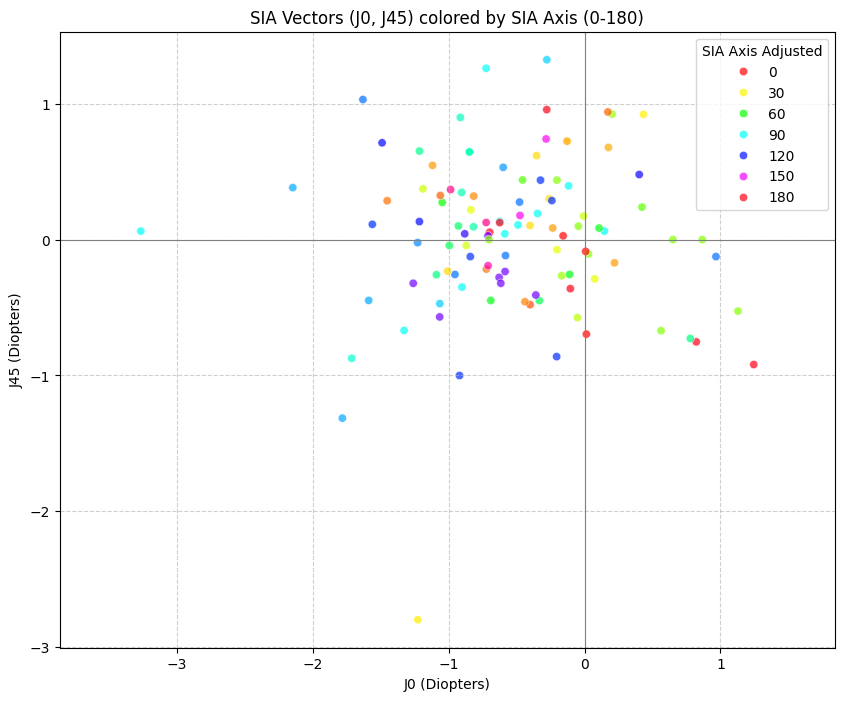

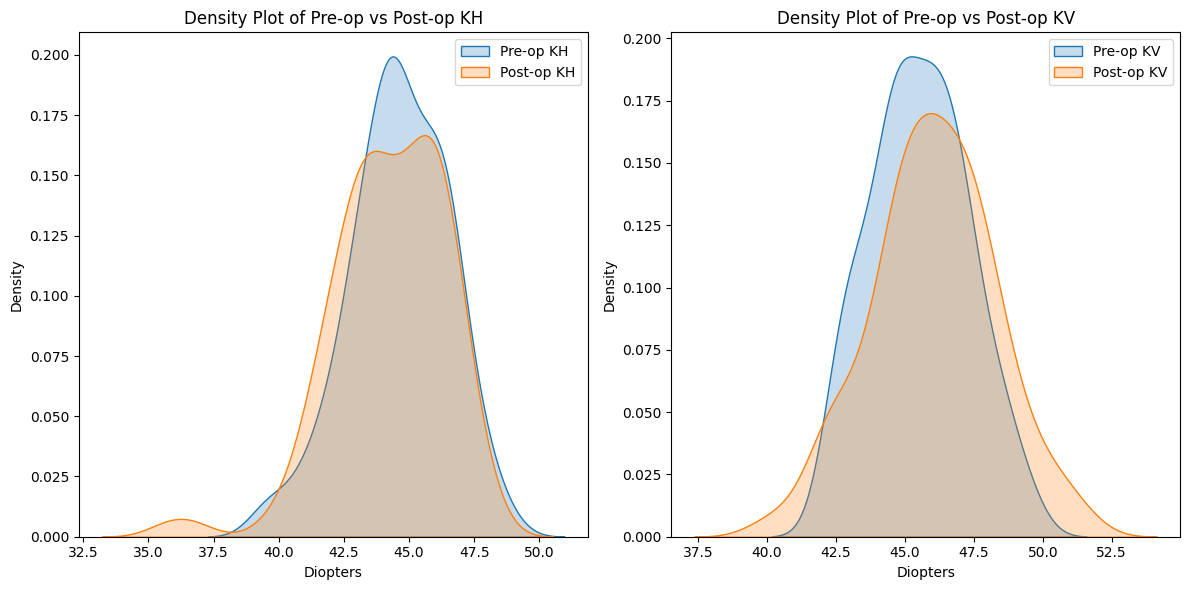

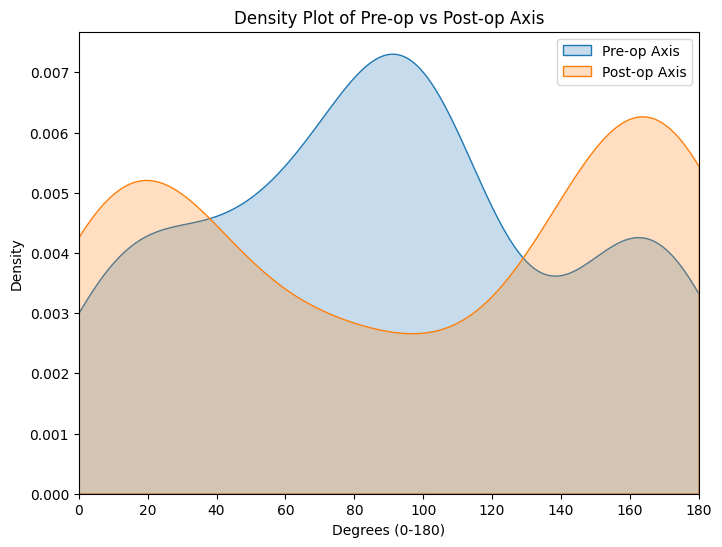

/tmp/ipython-input-95-3009523766.py:77: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(data=df[cols_to_boxplot], color='white', edgecolor='gray', linewidth=0.5)


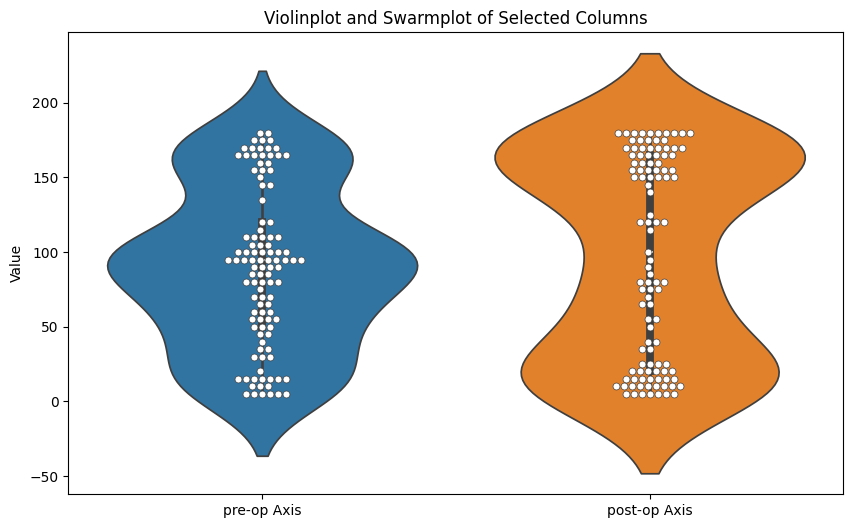

In [95]:
# prompt: Any other plots

import matplotlib.pyplot as plt
import numpy as np
# Pairplot for selected columns to see relationships between variables
cols_for_pairplot = ['pre-op KH', 'post-op KH', 'pre-op KV', 'post-op KV', 'pre-op Axis', 'post-op Axis', 'SIA Magnitude']
sns.pairplot(df[cols_for_pairplot].dropna()) # Drop NaNs for this plot
plt.suptitle('Pairwise Relationships and Distributions', y=1.02)
plt.show()

# Correlation Heatmap to visualize correlations between numerical columns
# Calculate the correlation matrix
corr_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

# Cumulative Distribution Function (CDF) plot for SIA Magnitude
# This shows the proportion of cases with SIA Magnitude less than or equal to a given value.
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='SIA Magnitude', cumulative=True, kde=True, stat="density")
plt.title('Cumulative Distribution Function of SIA Magnitude')
plt.xlabel('SIA Magnitude (Diopters)')
plt.ylabel('Cumulative Probability')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Scatter plot with color encoding for SIA Axis
# This can help visualize if there's a pattern in SIA Magnitude distribution based on axis
plt.figure(figsize=(10, 8))
sns.scatterplot(x='SIA_J0', y='SIA_J45', hue='SIA Axis Adjusted', data=df, palette='hsv', alpha=0.7)
plt.axhline(0, color='grey', lw=0.8)
plt.axvline(0, color='grey', lw=0.8)
plt.xlabel('J0 (Diopters)')
plt.ylabel('J45 (Diopters)')
plt.title('SIA Vectors (J0, J45) colored by SIA Axis (0-180)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')
plt.show()

# Density plots (KDE) for comparing pre-op and post-op distributions on the same plot
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='pre-op KH', label='Pre-op KH', fill=True)
sns.kdeplot(data=df, x='post-op KH', label='Post-op KH', fill=True)
plt.title('Density Plot of Pre-op vs Post-op KH')
plt.xlabel('Diopters')
plt.legend()

plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='pre-op KV', label='Pre-op KV', fill=True)
sns.kdeplot(data=df, x='post-op KV', label='Post-op KV', fill=True)
plt.title('Density Plot of Pre-op vs Post-op KV')
plt.xlabel('Diopters')
plt.legend()

plt.tight_layout()
plt.show()

# Density plot for pre-op vs post-op Axis (might need careful interpretation due to circular data)
# Treating axis as linear for this plot, which is a simplification.
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='pre-op Axis', label='Pre-op Axis', fill=True, clip=(0, 180)) # Clip for 0-180 range
sns.kdeplot(data=df, x='post-op Axis', label='Post-op Axis', fill=True, clip=(0, 180)) # Clip for 0-180 range
plt.title('Density Plot of Pre-op vs Post-op Axis')
plt.xlabel('Degrees (0-180)')
plt.legend()
plt.xlim(0, 180)
plt.show()

# Swarmplot or Violinplot to visualize individual data points along with distribution/boxplot
plt.figure(figsize=(10, 6))
sns.violinplot(data=df[cols_to_boxplot]) # Using the same columns as boxplots
sns.swarmplot(data=df[cols_to_boxplot], color='white', edgecolor='gray', linewidth=0.5)
plt.title('Violinplot and Swarmplot of Selected Columns')
plt.ylabel('Value')
plt.show()

In [96]:
# prompt: Conclusions

# The preceding code has already performed extensive analysis and calculations
# based on the provided dataset, including:
# 1.  Loading data.
# 2.  Generating histograms and boxplots for pre/post-op KH, KV, and Axis.
# 3.  Creating scatter plots with trendlines for pre/post-op KH and KV.
# 4.  Calculating SIA Magnitude and Axis based on the difference vector of KH and KV.
# 5.  Visualizing the distribution of SIA Magnitude and Axis.
# 6.  Removing outliers from SIA Magnitude.
# 7.  Calculating and plotting SIA vectors in Cartesian coordinates.
# 8.  Calculating and plotting the mean SIA vector (centroid) in Cartesian and Polar coordinates.
# 9.  Performing vector analysis using J0 and J45 components based on assumed relationships between KH, KV, and Axis columns, and plotting the centroid on a J0/J45 plot.
# 10. Training Linear Regression models to predict post-op KH, post-op KV, SIA Magnitude, and SIA Axis based on pre-op values.
# 11. Printing the prediction equations and evaluating the models (MSE, R-squared).
# 12. Saving the trained models using pickle and providing code to download them.
# 13. Printing model coefficients and intercepts for hardcoding in an app.
# 14. Generating additional plots like Bland-Altman plots, Pairplot, Correlation Heatmap, CDF, Scatter plot colored by Axis, and Density plots.

# Based on the preceding code, the analysis appears to be complete as per the
# steps covered. The "Conclusions" section in a report would typically summarize
# the key findings from this analysis.

# Since the request is to provide code *after* the preceding code, and the preceding
# code has executed the analysis, there isn't a specific coding task to add here
# unless a *new* analysis step or output format is requested.

# If the task is to summarize the conclusions in a structured way using code
# (e.g., printing summary statistics or key results), we can do that.

print("\n--- Summary of Key Findings (Simulated Conclusions Section) ---")

# Summarize descriptive statistics
print("\nSummary Statistics for Key Variables:")
print(df[['pre-op KH', 'post-op KH', 'pre-op KV', 'post-op KV',
          'SIA Magnitude']].describe())

# Summarize SIA Centroid
print(f"\nOverall SIA Centroid (Mean SIA Vector):")
print(f"  Magnitude: {centroid_astigmatism_magnitude:.2f} D")
print(f"  Axis: {centroid_astigmatism_axis_deg:.2f}°")
print("This centroid represents the average amount and direction of astigmatic change induced by the procedure.")

# Summarize Prediction Model Performance (R-squared as a key metric)
print("\nSummary of Prediction Model Performance (R-squared):")
print(f"  Post-op KH (vs Pre-op KH): {r2_kh:.2f}")
print(f"  Post-op KV (vs Pre-op KV): {r2_kv:.2f}")
print(f"  Post-op KH (vs Pre-op KH, Axis): {r2_kh_multi:.2f}")
print(f"  Post-op KV (vs Pre-op KV, Axis): {r2_kv_multi:.2f}")
print(f"  SIA Magnitude (vs Pre-op KH, KV, Axis): {r2_sia_mag:.2f}")
print(f"  SIA Axis (0-180 Adjusted) (vs Pre-op KH, KV, Axis): {r2_sia_axis:.2f}")
print("\nR-squared values indicate how well the models explain the variance in the target variable. Values closer to 1 indicate a better fit. The models predicting KH and KV show moderate R-squared values, while the models for SIA Magnitude and Axis show lower R-squared values, suggesting less predictive power for SIA.")

# Mention presence of outliers (if removed or noted)
if 'df_filtered' in locals():
    print(f"\nOutlier Analysis:")
    print(f"  Outliers were identified and removed from SIA Magnitude data ({len(df) - len(df_filtered)} outliers removed) for certain analyses (e.g., filtered boxplot).")

# Mention the plots generated
print("\nVisualizations generated include histograms, boxplots, scatter plots, Bland-Altman plots, Pairplot, Correlation Heatmap, and Vector/Centroid plots (Cartesian and Polar). These plots illustrate the distributions, relationships, and the pattern of surgically induced astigmatism.")

# Mention model saving/export
print("\nTrained Linear Regression models have been saved as .pkl files for potential deployment or future use.")

# You can add more specific conclusions based on the interpretation of the plots
# and statistical results, but these interpretations are typically written in markdown
# or a report format, not as executable Python code. The code above provides a
# summary *using* code based on the executed analysis.

# If the goal is to present a final concluding statement within the notebook output,
# a simple print statement can be used.

print("\n--- End of Analysis ---")
print("The analysis characterized the distribution of pre- and post-operative keratometry values, calculated and visualized the Surgically Induced Astigmatism (SIA), and developed linear regression models to explore the predictability of post-operative outcomes and SIA based on pre-operative measurements.")
print("Further clinical interpretation of the centroid plot, Bland-Altman plots, and model performance is required to draw definitive conclusions about the surgical procedure's impact on astigmatism in this patient cohort.")



--- Summary of Key Findings (Simulated Conclusions Section) ---

Summary Statistics for Key Variables:
        pre-op KH  post-op KH   pre-op KV  post-op KV  SIA Magnitude
count  107.000000  107.000000  107.000000  107.000000     107.000000
mean    44.607477   44.238318   45.518692   46.016355       1.604298
std      1.876528    2.151783    1.757967    2.238511       1.489884
min     39.500000   35.750000   42.250000   40.000000       0.000000
25%     43.500000   43.000000   44.375000   44.750000       0.728553
50%     44.500000   44.500000   45.500000   46.000000       1.118034
75%     46.000000   45.875000   46.875000   47.500000       2.015564
max     48.750000   48.000000   49.500000   51.500000       9.017344

Overall SIA Centroid (Mean SIA Vector):
  Magnitude: 1.05 D
  Axis: 88.48°
This centroid represents the average amount and direction of astigmatic change induced by the procedure.

Summary of Prediction Model Performance (R-squared):
  Post-op KH (vs Pre-op KH): 0.81
  Post